<a href="https://colab.research.google.com/github/SageChisanga/Data-Science/blob/main/anglo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title installations
!pip install -q textblob
!python -m textblob.download_corpora
!pip install ace_tools

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [ ]:
# @title import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk
from collections import Counter

In [ ]:
# @title downloads
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# @title Load and clean dataset
df = pd.read_excel('/content/Baseline Assessment Tool.xlsx')
df.columns = df.columns.str.strip()  # Clean column headers

# df.columns.tolist()
df['Industry/Sector of the business'] = df['Industry/Sector of the business'].astype(str).str.strip().str.title()
# Standardize Location column to remove duplicates caused by inconsistencies
df['Location:'] = df['Location:'].astype(str).str.strip().str.title()

In [ ]:
# --- UPDATE LOCATIONS ---
location_map = {
    'Mogwase': 'Mogalakwena'  # Merge Mogwase under Mogalakwena
}
df['Location:'] = df['Location:'].replace(location_map)

# --- UPDATE INDUSTRY GROUPINGS ---
industry_merge = {
    # Hospitality and Support Services
    'Catering, Food And Beverages': 'Hospitality and Support Services',
    'Mining Support Services': 'Hospitality and Support Services',

    # Infrastructure and Engineering
    'Mine Engineering And Technical': 'Infrastructure and Engineering',
    'Civil Engineering': 'Infrastructure and Engineering',
    'Construction': 'Infrastructure and Engineering',

    # Utilities and Technical Services
    'Electrical, Gas, Air Conditioning': 'Utilities and Technical Services',
    'Machine Repair And Installations': 'Utilities and Technical Services',

    # ICT and Digital Services
    'Ict': 'ICT and Digital Services',

    # Manufacturing and Industrial
    'Manufacturing': 'Manufacturing and Industrial',
    'Mine Equipment Supplies': 'Manufacturing and Industrial',

    # Ground preparation and excavation
    'Mining And Quarrying': 'Ground preparation and excavation',

    # Security Services
    'Security And Investigations': 'Security Services',

    # Transport and Tourism
    'Transport And Tour Operator': 'Transport and Tourism',

    # Keep 'Other' as is
    'Other': 'Other'
}

df['Industry/Sector of the business'] = df['Industry/Sector of the business'].replace(industry_merge)

# Display the cleaned unique values for validation
unique_locations = df['Location:'].unique()
unique_industries = df['Industry/Sector of the business'].unique()

(unique_locations, unique_industries)

(array(['Mogalakwena', 'Polokwane', 'Rustenburg', 'Amandelbult'],
       dtype=object),
 array(['Ground Preparation And Excavation',
        'Infrastructure And Engineering', 'Security Services',
        'Utilities And Technical Services',
        'Hospitality And Support Services', 'Ict And Digital Services',
        'Manufacturing And Industrial', 'Transport And Tourism',
        'Energy And Fuel Services'], dtype=object))

🔹 Business Profile by Industry (Average Years in Operation):


,Years in Bus
Industry,
Energy And Fuel Services,9.0
Ground Preparation And Excavation,10.0
Hospitality And Support Services,8.9
Ict And Digital Services,8.5
Infrastructure And Engineering,9.2
Manufacturing And Industrial,8.2
Security Services,4.0
Transport And Tourism,10.8
Utilities And Technical Services,8.6


🔹 Business Profile by Site (Average Years in Operation):


,Years in Bus
Location,
Amandelbult,9.3
Mogalakwena,8.4
Polokwane,12.2
Rustenburg,7.4


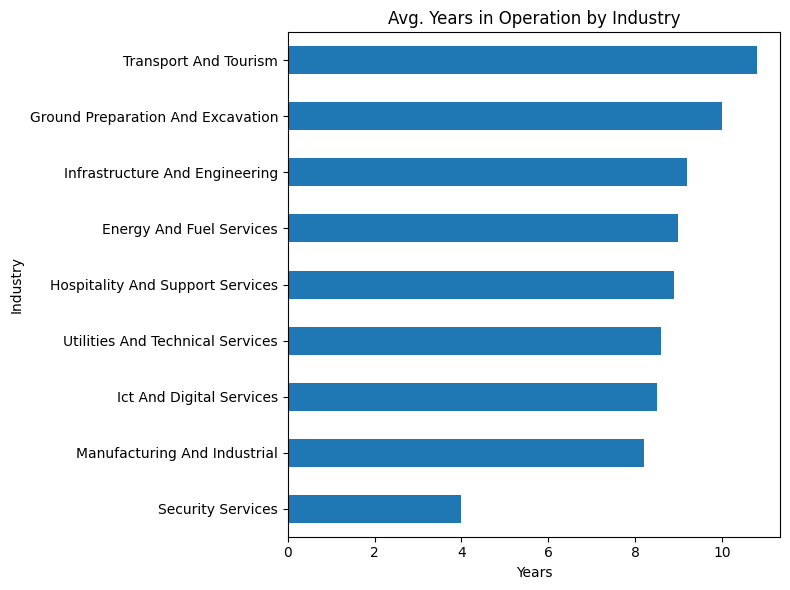

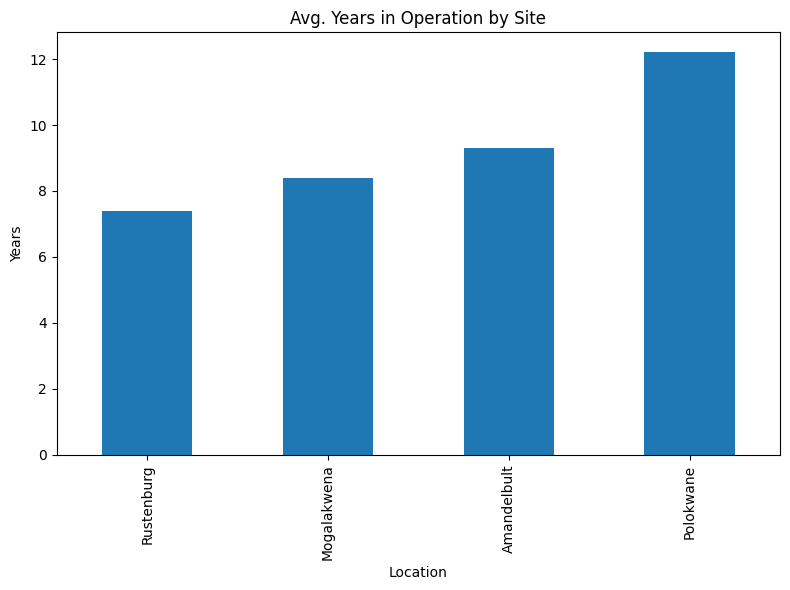

🔹 Employment Summary by Site:


,Total Permanent,Total Temporary,Jobs at Risk
Location:,,,
Amandelbult,93,38,95
Mogalakwena,251,153,334
Polokwane,77,84,146
Rustenburg,229,33,205


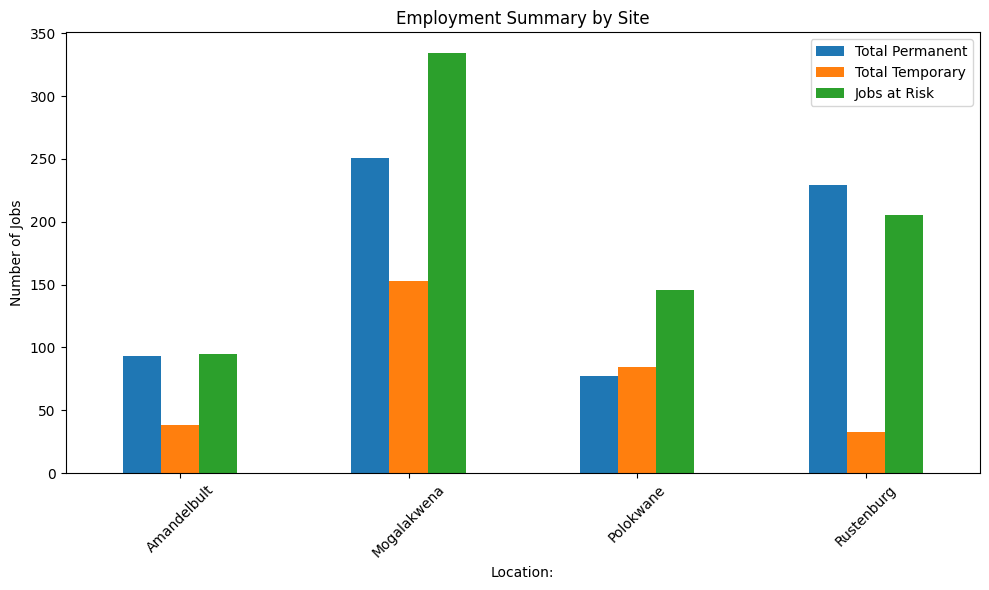

🔹 Turnover Stage Distribution by Site (ToC-aligned %):


Turnover Stage (ToC),Early,Mature,Mid
Location:,,,
Amandelbult,21.4,57.1,21.4
Mogalakwena,0.0,70.4,29.6
Polokwane,0.0,66.7,33.3
Rustenburg,0.0,50.0,50.0


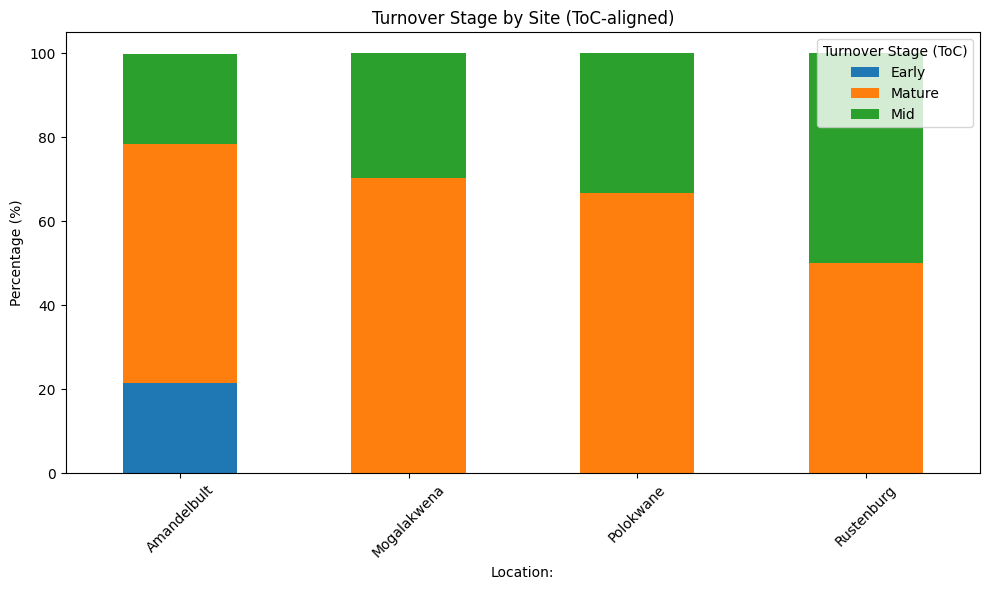

🔹 Average NPAT by Industry:


,NPAT
Industry,
Energy And Fuel Services,510651.0
Ground Preparation And Excavation,252300.0
Hospitality And Support Services,412075.0
Ict And Digital Services,863333.0
Infrastructure And Engineering,307374.0
Manufacturing And Industrial,272151.0
Security Services,162082.0
Transport And Tourism,383829.0
Utilities And Technical Services,295346.0


🔹 Average NPAT by Site:


,NPAT
Location,
Amandelbult,180798.0
Mogalakwena,448225.0
Polokwane,580856.0
Rustenburg,142705.0


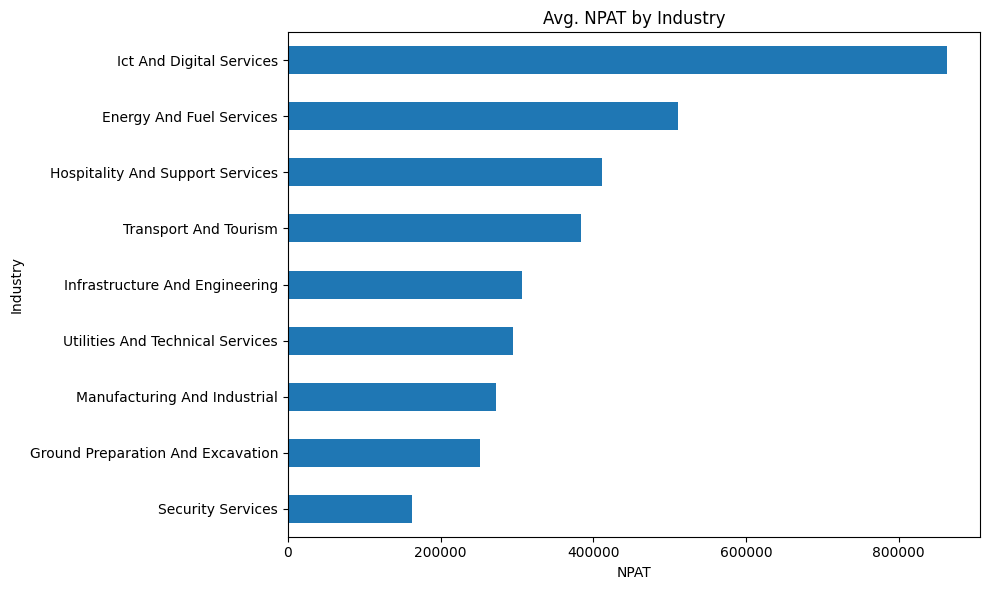

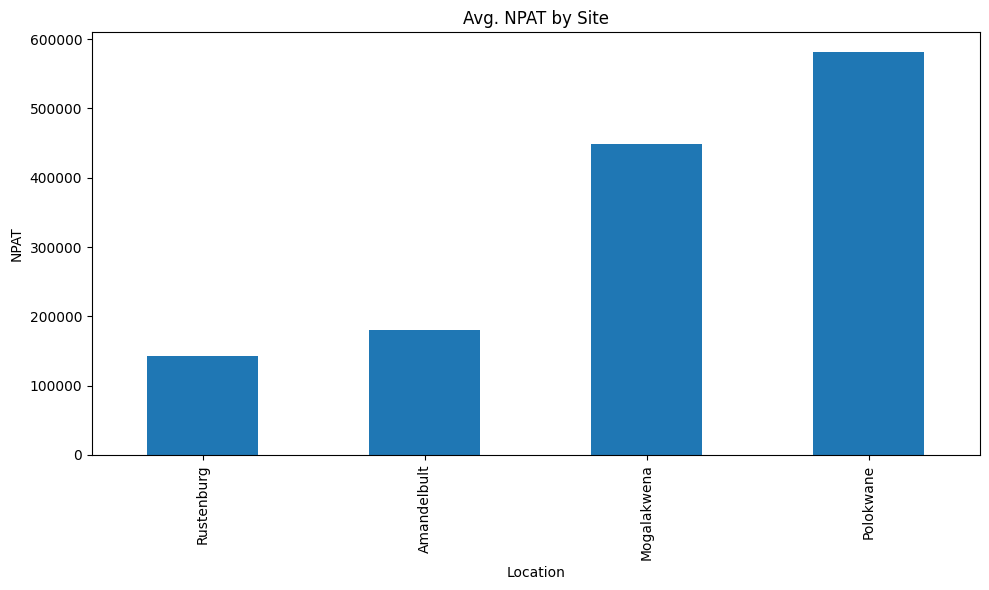

🔹 Sentiment on Sustainability by Site:


,Sustainability Sentiment
Location,
Amandelbult,-0.03
Mogalakwena,-0.10
Polokwane,-0.12
Rustenburg,0.11


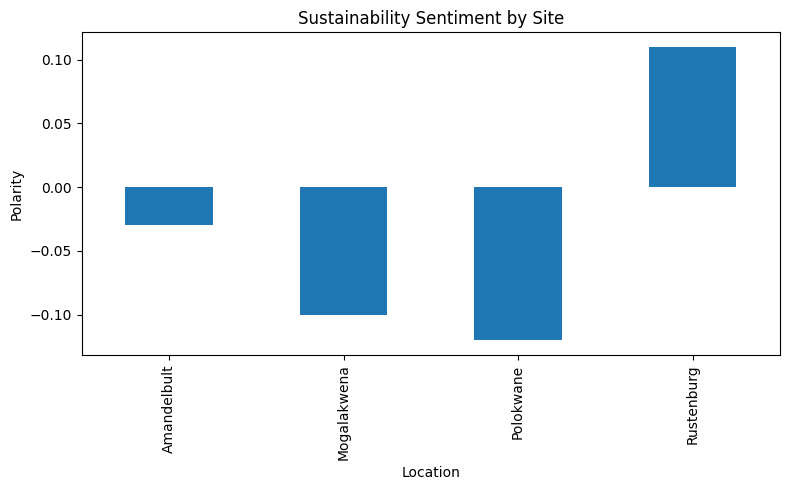

🔹 Sentiment on Competitiveness by Site:


,Competitiveness Sentiment
Location,
Amandelbult,0.12
Mogalakwena,0.10
Polokwane,0.04
Rustenburg,0.24


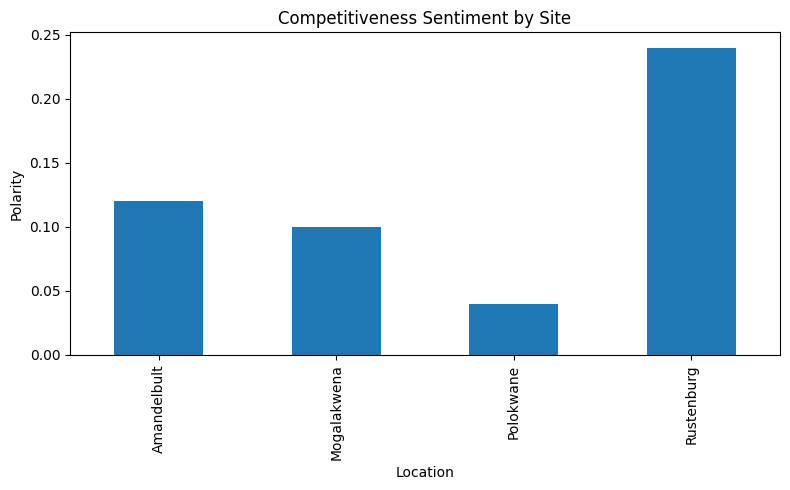

🔹 Top Keywords - Sustainability Issues:
['base' 'business' 'customer' 'customers' 'engagement' 'financial' 'lack'
 'management' 'skills' 'weak']
🔹 Top Keywords - Competitiveness:
['business' 'customer' 'market' 'marketing' 'new' 'offer' 'products'
 'quality' 'service' 'services']


In [ ]:
# @title SECTION 1: Profiling and Demographics
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns


# --- 1A: BUSINESS PROFILES BY INDUSTRY AND SITE ---
profile_df = df[['Location:', 'Industry/Sector of the business', 'Year in Operation:']].dropna()
profile_df.columns = ['Location', 'Industry', 'Years in Bus']
profile_df['Years in Bus'] = pd.to_numeric(profile_df['Years in Bus'], errors='coerce')

industry_summary = profile_df.groupby('Industry')['Years in Bus'].mean().round(1)
site_summary = profile_df.groupby('Location')['Years in Bus'].mean().round(1)

print("🔹 Business Profile by Industry (Average Years in Operation):")
display(industry_summary)

print("🔹 Business Profile by Site (Average Years in Operation):")
display(site_summary)

# Plot: Industry vs Years in Operation
industry_summary.sort_values().plot(kind='barh', title='Avg. Years in Operation by Industry', figsize=(8, 6))
plt.xlabel("Years")
plt.tight_layout()
plt.show()

# Plot: Site vs Years in Operation
site_summary.sort_values().plot(kind='bar', title='Avg. Years in Operation by Site', figsize=(8, 6))
plt.ylabel("Years")
plt.tight_layout()
plt.show()

# --- 1B: EMPLOYMENT SUMMARY ---
emp_df = df[['Location:',
             'How many permanent (Full time) MALE employees does the business have? These should work minimum of 21 hours a week and earn National minimum wage and above.',
             'How many permanent (Full time) FEMALE employees does the business have? These should work minimum of 21 hours a week and earn National minimum wage and above.',
             'How many temporary (part time) MALE employees does the business have? These should work 9-20 hours a week and earn National minimum wage and above',
             'How many temporary (part time) FEMALE employees does the business have? These should work 9-20 hours a week and earn National minimum wage and above',
             'How many female jobs within the business do you consider to be at risk due to economic changes, particularly those related to the mining industry?',
             'How many male jobs within the business do you consider to be at risk due to economic changes, particularly those related to the mining industry?']].copy()

emp_df.fillna(0, inplace=True)
emp_df['Total Permanent'] = emp_df.iloc[:, 1] + emp_df.iloc[:, 2]
emp_df['Total Temporary'] = emp_df.iloc[:, 3] + emp_df.iloc[:, 4]
emp_df['Jobs at Risk'] = emp_df.iloc[:, 5] + emp_df.iloc[:, 6]

employment_summary = emp_df.groupby('Location:')[['Total Permanent', 'Total Temporary', 'Jobs at Risk']].sum().astype(int)

print("🔹 Employment Summary by Site:")
display(employment_summary)

# Plot: Employment
employment_summary.plot(kind='bar', stacked=False, figsize=(10, 6), title='Employment Summary by Site')
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 1C: TURNOVER STAGE (ToC-aligned Classification) ---

# Ensure numeric conversions
df['Annual Turnover 2024'] = pd.to_numeric(df['State the annual turnover for 2024 as a number/amount'], errors='coerce')
df['NPAT 2024'] = pd.to_numeric(df['State the 2024 NPAT as a number'], errors='coerce')
df['Employees'] = df[
    ['How many permanent (Full time) MALE employees does the business have? These should work minimum of 21 hours a week and earn National minimum wage and above.',
     'How many permanent (Full time) FEMALE employees does the business have? These should work minimum of 21 hours a week and earn National minimum wage and above.',
     'How many temporary (part time) MALE employees does the business have? These should work 9-20 hours a week and earn National minimum wage and above',
     'How many temporary (part time) FEMALE employees does the business have? These should work 9-20 hours a week and earn National minimum wage and above']
].sum(axis=1)

# Compute profit margin
df['Profit Margin'] = (df['NPAT 2024'] / df['Annual Turnover 2024']) * 100
df['Profit Margin'] = df['Profit Margin'].fillna(0)

# ToC-aligned turnover stage classification
def toc_turnover_stage(row):
    if (
        row['Annual Turnover 2024'] > 10_000_000 or
        row['Profit Margin'] >= 20 or
        row['Employees'] > 10
    ):
        return 'Mature'
    elif (
        3_000_000 <= row['Annual Turnover 2024'] <= 10_000_000 or
        10 <= row['Profit Margin'] < 20 or
        5 <= row['Employees'] <= 10
    ):
        return 'Mid'
    elif (
        row['Annual Turnover 2024'] < 3_000_000 or
        row['Profit Margin'] < 10 or
        row['Employees'] < 5
    ):
        return 'Early'
    else:
        return 'Unclassified'

df['Turnover Stage (ToC)'] = df.apply(toc_turnover_stage, axis=1)

# Group and calculate percentage distribution by site
turnover_toc_df = df[['Location:', 'Turnover Stage (ToC)']].dropna()
toc_counts = turnover_toc_df.groupby(['Location:', 'Turnover Stage (ToC)']).size().unstack(fill_value=0)
toc_pct = toc_counts.div(toc_counts.sum(axis=1), axis=0).multiply(100).round(1)

print("🔹 Turnover Stage Distribution by Site (ToC-aligned %):")
display(toc_pct)

# Plot the results
toc_pct.plot(kind='bar', stacked=True, figsize=(10, 6), title='Turnover Stage by Site (ToC-aligned)')
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- 1D: NPAT BY SECTOR AND SITE ---
df['NPAT'] = df[['State the 2022 NPAT as a number', 'State the 2023 NPAT as a number', 'State the 2024 NPAT as a number']].mean(axis=1)

npat_df = df[['Location:', 'Industry/Sector of the business', 'NPAT']].copy()
npat_df.columns = ['Location', 'Industry', 'NPAT']
npat_df['NPAT'] = pd.to_numeric(npat_df['NPAT'], errors='coerce')

npat_sector = npat_df.groupby('Industry')['NPAT'].mean().round(0)
npat_site = npat_df.groupby('Location')['NPAT'].mean().round(0)

print("🔹 Average NPAT by Industry:")
display(npat_sector)

print("🔹 Average NPAT by Site:")
display(npat_site)

# Plot: NPAT by Sector and Site
npat_sector.sort_values().plot(kind='barh', figsize=(10, 6), title='Avg. NPAT by Industry')
plt.xlabel("NPAT")
plt.tight_layout()
plt.show()

npat_site.sort_values().plot(kind='bar', figsize=(10, 6), title='Avg. NPAT by Site')
plt.ylabel("NPAT")
plt.tight_layout()
plt.show()

# --- 1E: QUALITATIVE THEMATIC & SENTIMENT ANALYSIS ---
qual_cols = ['Location:', 'What issues affect sustainability in the business?', 'What is the SME doing to ensure it remains competitive/relevant?']

if all(col in df.columns for col in qual_cols):
    qual_df = df[qual_cols].dropna()
    qual_df.columns = ['Location', 'Sustainability', 'Competitiveness']

    qual_df['Sustainability Sentiment'] = qual_df['Sustainability'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    qual_df['Competitiveness Sentiment'] = qual_df['Competitiveness'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    sust_sent = qual_df.groupby('Location')['Sustainability Sentiment'].mean().round(2)
    comp_sent = qual_df.groupby('Location')['Competitiveness Sentiment'].mean().round(2)

    print("🔹 Sentiment on Sustainability by Site:")
    display(sust_sent)
    sust_sent.plot(kind='bar', title='Sustainability Sentiment by Site', ylabel='Polarity', figsize=(8, 5))
    plt.tight_layout()
    plt.show()

    print("🔹 Sentiment on Competitiveness by Site:")
    display(comp_sent)
    comp_sent.plot(kind='bar', title='Competitiveness Sentiment by Site', ylabel='Polarity', figsize=(8, 5))
    plt.tight_layout()
    plt.show()

    # Top Keywords
    print("🔹 Top Keywords - Sustainability Issues:")
    vec_sust = CountVectorizer(stop_words='english', max_features=10)
    vec_sust.fit_transform(qual_df['Sustainability'])
    print(vec_sust.get_feature_names_out())

    print("🔹 Top Keywords - Competitiveness:")
    vec_comp = CountVectorizer(stop_words='english', max_features=10)
    vec_comp.fit_transform(qual_df['Competitiveness'])
    print(vec_comp.get_feature_names_out())


🔹 Gender Distribution:


,count
Gender,
Male,33
Female,30
Prefer Not To Say,1


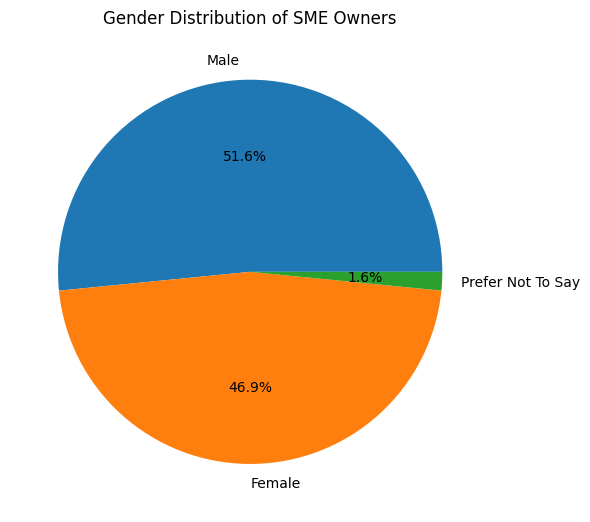

🔹 Age Group Distribution:


,count
Age Group,
Above 55,3
Between 35 And 55,15
Between 36 And 55,30
Less Than 35,8
Less Than 36,8


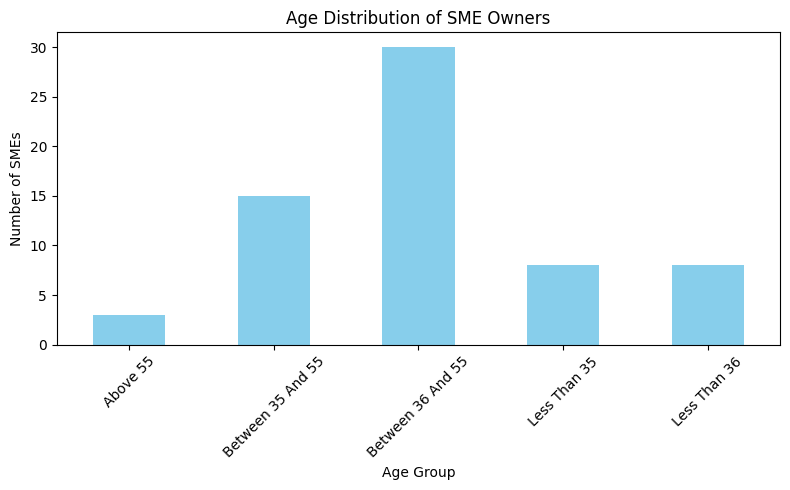

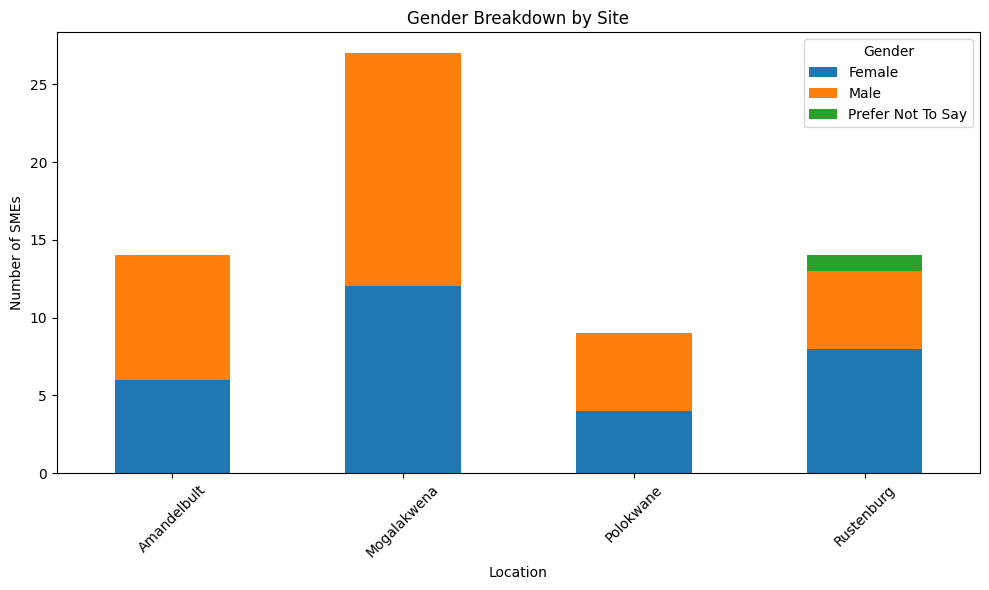

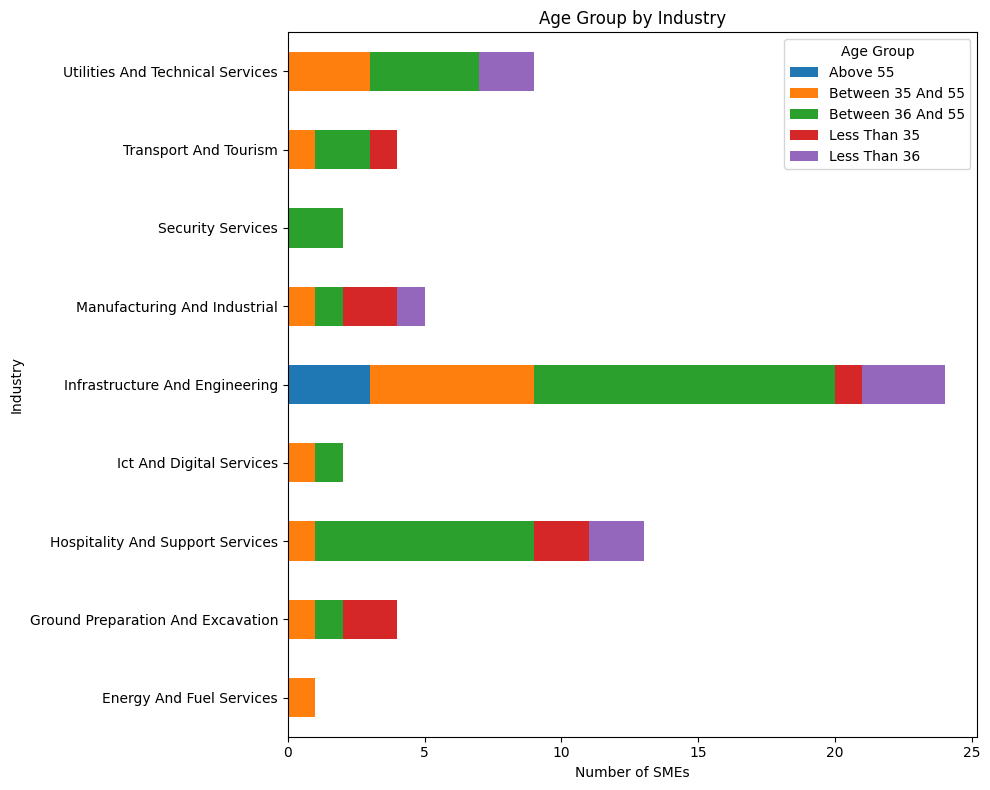

In [ ]:
# --- GENDER AND AGE GROUP PROFILING ---

# Clean column names
gender_col = 'Gender'
age_col = 'Kindly state age range'

# Filter relevant data
demo_df = df[[gender_col, age_col, 'Location:', 'Industry/Sector of the business']].copy()
demo_df.columns = ['Gender', 'Age Group', 'Location', 'Industry']

# Clean data
demo_df = demo_df.dropna(subset=['Gender', 'Age Group'])
demo_df['Gender'] = demo_df['Gender'].str.strip().str.title()
demo_df['Age Group'] = demo_df['Age Group'].str.strip().str.title()

# Gender distribution
gender_counts = demo_df['Gender'].value_counts()
print("🔹 Gender Distribution:")
display(gender_counts)

# Plot: Gender Distribution
gender_counts.plot(kind='pie', autopct='%1.1f%%', title='Gender Distribution of SME Owners', figsize=(6, 6), ylabel='')
plt.tight_layout()
plt.show()

# Age group distribution
age_counts = demo_df['Age Group'].value_counts().sort_index()
print("🔹 Age Group Distribution:")
display(age_counts)

# Plot: Age Group Distribution
age_counts.plot(kind='bar', title='Age Distribution of SME Owners', color='skyblue', figsize=(8, 5))
plt.ylabel("Number of SMEs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cross-tab: Gender by Location
gender_loc = pd.crosstab(demo_df['Location'], demo_df['Gender'])
gender_loc.plot(kind='bar', stacked=True, title='Gender Breakdown by Site', figsize=(10, 6))
plt.ylabel("Number of SMEs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cross-tab: Age by Industry
age_ind = pd.crosstab(demo_df['Industry'], demo_df['Age Group'])
age_ind.plot(kind='barh', stacked=True, figsize=(10, 8), title='Age Group by Industry')
plt.xlabel("Number of SMEs")
plt.tight_layout()
plt.show()


📊 Sentiment Scores by Site:


,Sustainability Sentiment,Competitiveness Sentiment
Location,,
Amandelbult,-0.03,0.12
Mogalakwena,-0.10,0.10
Polokwane,-0.12,0.04
Rustenburg,0.11,0.24


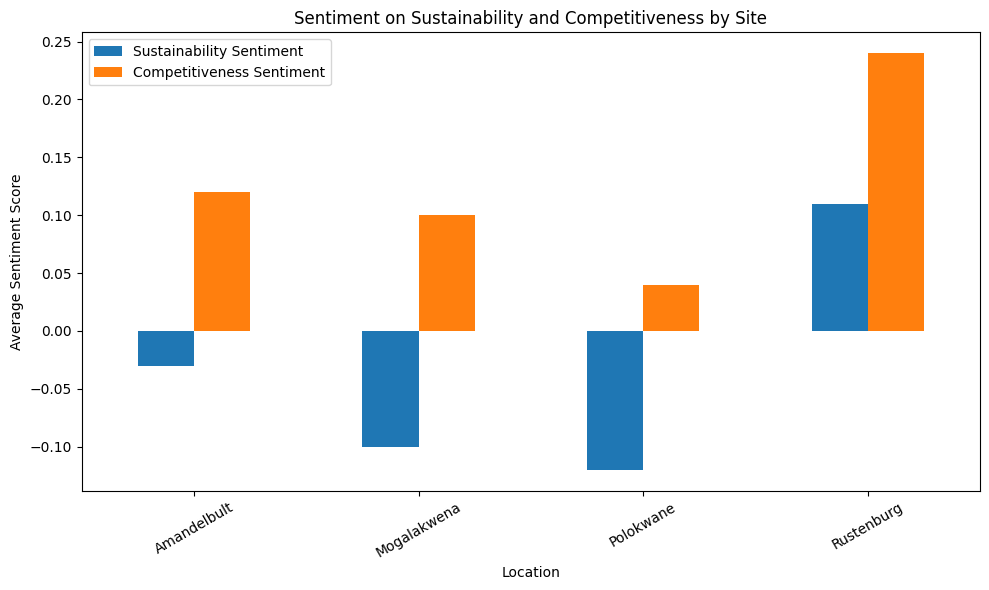


🔍 Top Keywords - Sustainability Issues:
['base' 'business' 'customer' 'customers' 'engagement' 'financial' 'lack'
 'management' 'skills' 'weak']

🔍 Top Keywords - Competitiveness Actions:
['business' 'customer' 'market' 'marketing' 'new' 'offer' 'products'
 'quality' 'service' 'services']

📍 Site-Level Themes - Sustainability:


{'Amandelbult': [('business', 10),
  ('client', 4),
  ('strategy', 3),
  ('value', 2),
  ('proposition', 2)],
 'Mogalakwena': [('skills', 14),
  ('customer', 14),
  ('engagement', 12),
  ('management', 8),
  ('business', 7)],
 'Polokwane': [('skills', 10),
  ('engagement', 8),
  ('customer', 8),
  ('strategic', 4),
  ('management', 4)],
 'Rustenburg': [('business', 8),
  ('client', 6),
  ('financial', 3),
  ('which', 3),
  ('contract', 3)]}


📍 Site-Level Themes - Competitiveness:


{'Amandelbult': [('market', 4),
  ('trends', 3),
  ('product', 3),
  ('business', 3),
  ('engaging', 2)],
 'Mogalakwena': [('service', 9),
  ('services', 8),
  ('market', 7),
  ('products', 7),
  ('quality', 6)],
 'Polokwane': [('marketing', 4),
  ('skills', 4),
  ('training', 3),
  ('strategic', 3),
  ('management', 3)],
 'Rustenburg': [('service', 6),
  ('provide', 3),
  ('client', 3),
  ('business', 3),
  ('providing', 2)]}

In [ ]:
# SECTION 1: QUALITATIVE ANALYSIS – Sustainability and Competitiveness Insights

# Ensure relevant columns are available
qual_cols = [
    'Location:',
    'What issues affect sustainability in the business?',
    'What is the SME doing to ensure it remains competitive/relevant?'
]
df_qual = df[qual_cols].dropna()
df_qual.columns = ['Location', 'Sustainability', 'Competitiveness']

# --- Sentiment Analysis ---
df_qual['Sustainability Sentiment'] = df_qual['Sustainability'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_qual['Competitiveness Sentiment'] = df_qual['Competitiveness'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# --- Average sentiment by site ---
sentiment_summary = df_qual.groupby('Location')[['Sustainability Sentiment', 'Competitiveness Sentiment']].mean().round(2)
print("📊 Sentiment Scores by Site:")
display(sentiment_summary)

# --- Visualize Sentiment Scores ---
sentiment_summary.plot(kind='bar', figsize=(10, 6), title='Sentiment on Sustainability and Competitiveness by Site')
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- Thematic Keyword Extraction ---
def extract_keywords(text_series, top_n=10):
    text = ' '.join(text_series.dropna().astype(str))
    vec = CountVectorizer(stop_words='english', max_features=top_n)
    X = vec.fit_transform([text])
    return vec.get_feature_names_out()

# Top sustainability issues
print("\n🔍 Top Keywords - Sustainability Issues:")
sustainability_keywords = extract_keywords(df_qual['Sustainability'])
print(sustainability_keywords)

# Top competitiveness themes
print("\n🔍 Top Keywords - Competitiveness Actions:")
competitiveness_keywords = extract_keywords(df_qual['Competitiveness'])
print(competitiveness_keywords)

# --- Site-level keyword frequency (optional deep dive) ---
def site_keywords(df, column):
    keywords_by_site = {}
    for site, group in df.groupby('Location'):
        all_text = ' '.join(group[column].dropna().astype(str))
        blob = TextBlob(all_text)
        keywords = [word.lower() for word in blob.words if len(word) > 4]
        top_keywords = Counter(keywords).most_common(5)
        keywords_by_site[site] = top_keywords
    return keywords_by_site

print("\n📍 Site-Level Themes - Sustainability:")
display(site_keywords(df_qual, 'Sustainability'))

print("\n📍 Site-Level Themes - Competitiveness:")
display(site_keywords(df_qual, 'Competitiveness'))


📊 Aggregate Skills Gaps (% SMEs with reported gap):


,0
Financial Management,NaN
Business Management,NaN
Marketing and Sales,NaN
Human Resources,NaN
Customer Service,NaN
Regulatory & Compliance,NaN
Supply Chain & Procurement,NaN
Project Management,NaN


📍 Site-Specific Skills Gaps (% SMEs with reported gap):


,Financial Management,Business Management,Marketing and Sales,Human Resources,Customer Service,Regulatory & Compliance,Supply Chain & Procurement,Project Management
Location:,,,,,,,,
Amandelbult,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mogalakwena,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Polokwane,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rustenburg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


⚠️ No valid numeric data available to display in heatmap.

🔹 STRENGTHS CLUSTER


,Good Systems,Strong Cashflow,Expert Skills,Unique product or service
Industry/Sector of the business,,,,
Energy And Fuel Services,2.00,2.00,2.00,2.00
Ground Preparation And Excavation,2.67,1.67,2.67,3.00
Hospitality And Support Services,1.33,1.80,2.00,2.10
Ict And Digital Services,1.50,1.50,2.50,2.00
Infrastructure And Engineering,1.93,1.67,2.27,1.67
Manufacturing And Industrial,2.40,1.75,1.75,2.80
Security Services,2.00,1.50,2.00,2.00
Transport And Tourism,1.33,2.00,2.00,2.00
Utilities And Technical Services,2.00,1.67,3.00,2.50


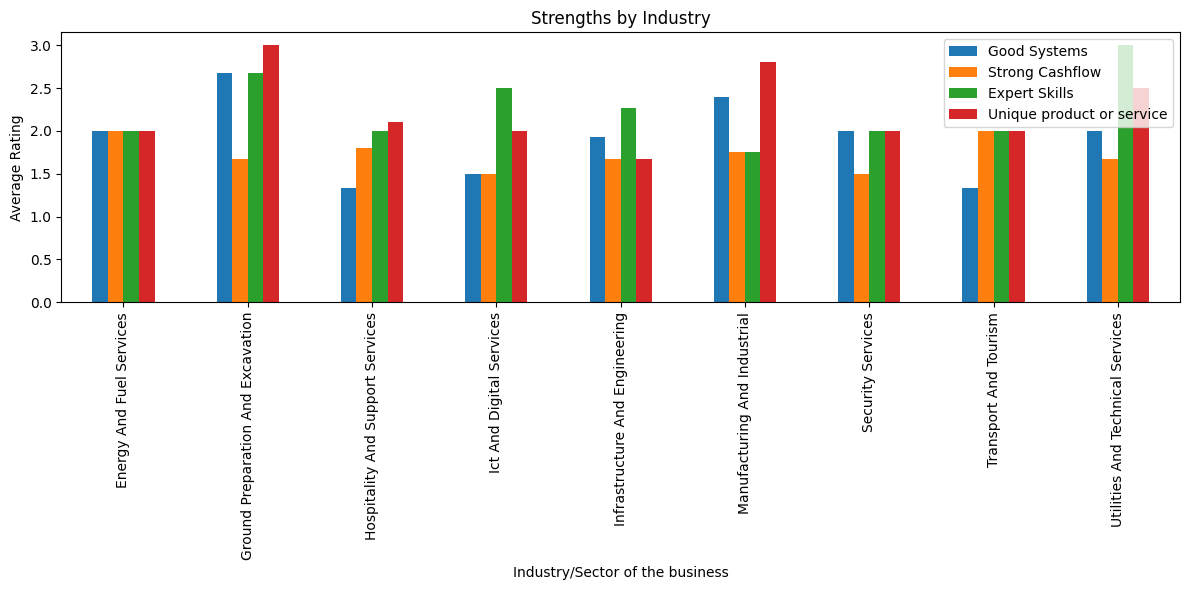

,Good Systems,Strong Cashflow,Expert Skills,Unique product or service
Location:,,,,
Amandelbult,1.90,1.82,2.10,2.25
Mogalakwena,2.00,1.70,2.06,2.30
Polokwane,1.43,1.50,3.00,1.86
Rustenburg,1.62,1.73,2.00,2.00


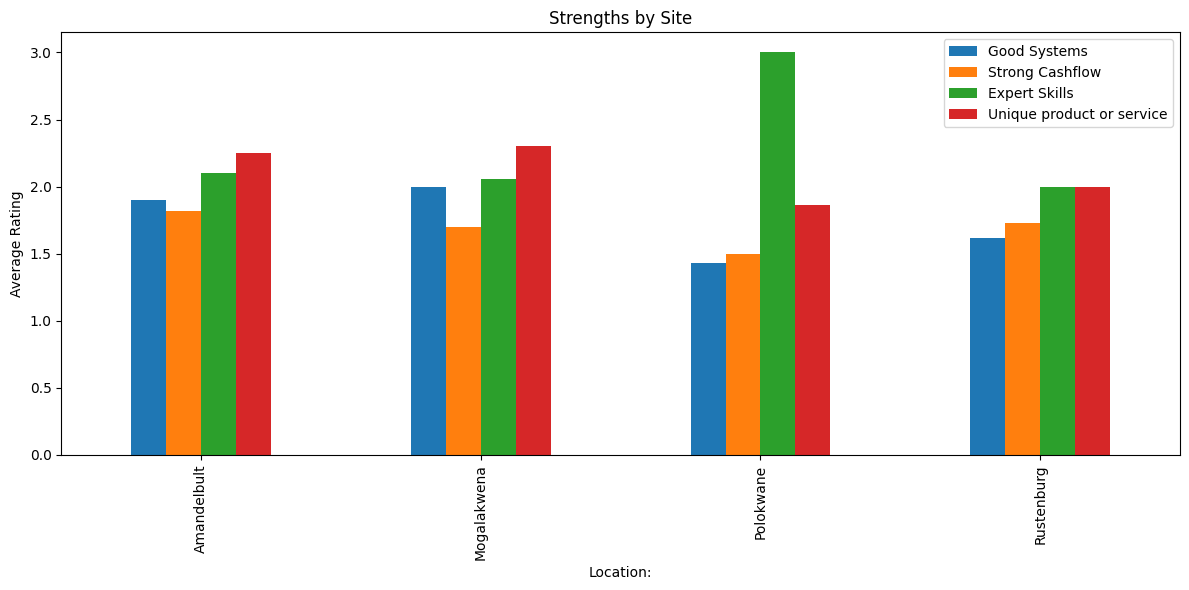


🔹 WEAKNESSES CLUSTER


,Lack of funding,Lack of tenders,High Staff turnover,Stiff market competition,Alternative products/services in the market
Industry/Sector of the business,,,,,
Energy And Fuel Services,NaN,NaN,NaN,2.0,NaN
Ground Preparation And Excavation,2.0,2.0,2.0,2.0,NaN
Hospitality And Support Services,2.0,2.0,2.0,NaN,2.0
Ict And Digital Services,2.0,2.0,2.0,NaN,2.0
Infrastructure And Engineering,2.0,2.0,2.0,2.0,2.0
Manufacturing And Industrial,2.0,2.0,2.0,2.0,2.0
Security Services,2.0,2.0,2.0,2.0,2.0
Transport And Tourism,2.0,2.0,NaN,2.0,NaN
Utilities And Technical Services,2.0,2.0,NaN,2.0,2.0


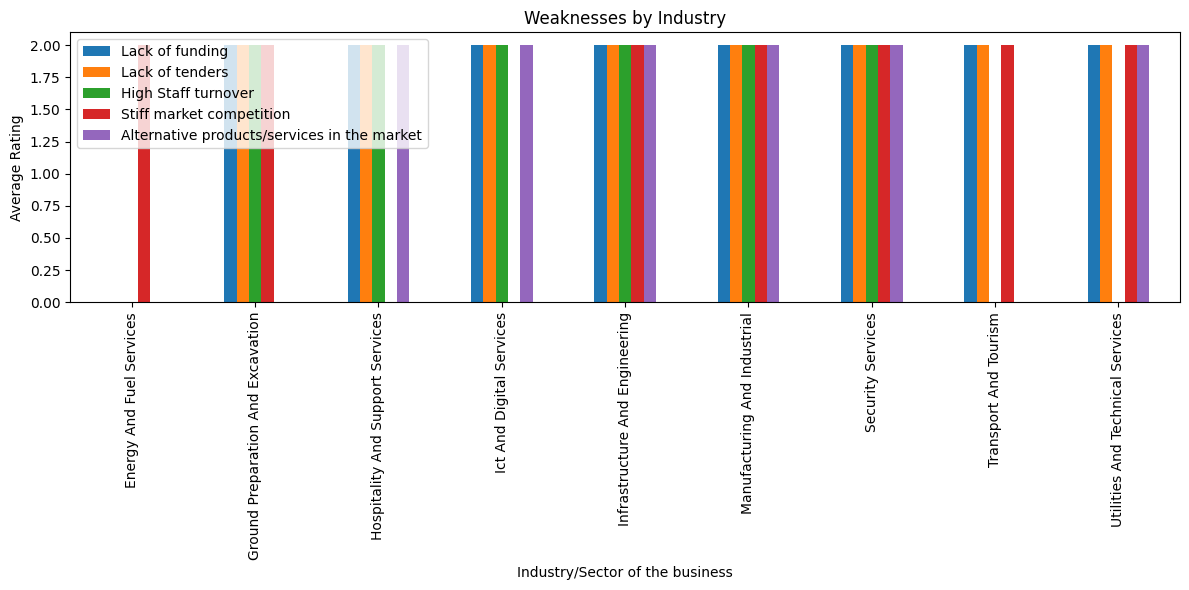

,Lack of funding,Lack of tenders,High Staff turnover,Stiff market competition,Alternative products/services in the market
Location:,,,,,
Amandelbult,2.0,2.0,2.0,2.0,2.0
Mogalakwena,2.0,2.0,2.0,2.0,2.0
Polokwane,2.0,2.0,2.0,2.0,2.0
Rustenburg,2.0,2.0,2.0,2.0,2.0


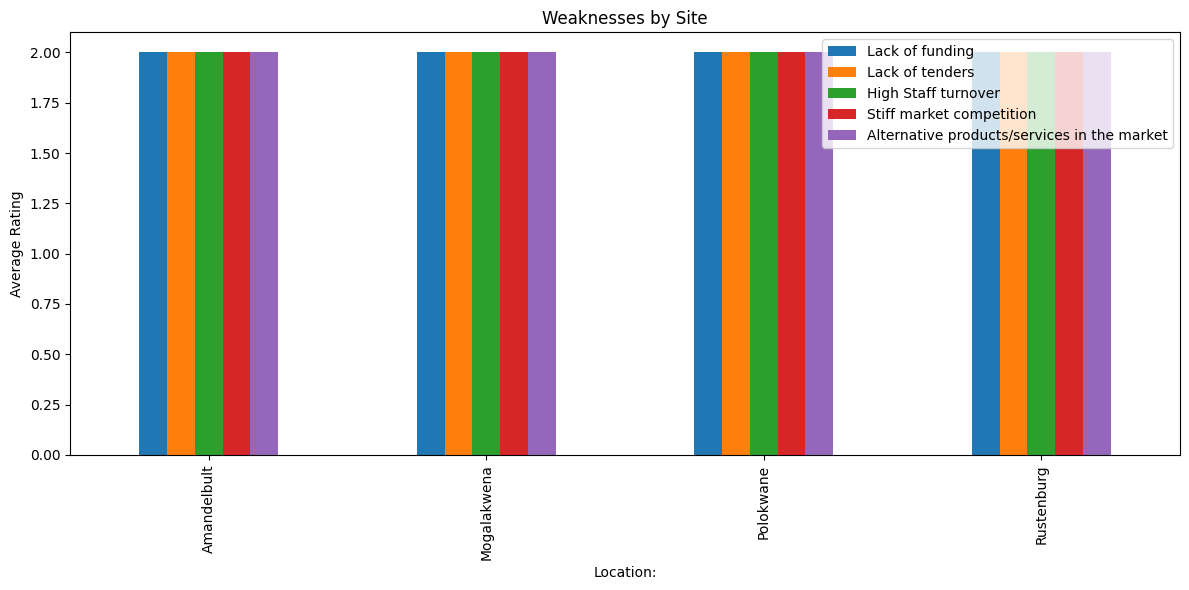


🔹 OPPORTUNITIES CLUSTER


,New product lines,Other business (different sector)
Industry/Sector of the business,,
Energy And Fuel Services,NaN,NaN
Ground Preparation And Excavation,NaN,NaN
Hospitality And Support Services,2.0,2.0
Ict And Digital Services,NaN,2.0
Infrastructure And Engineering,2.0,2.0
Manufacturing And Industrial,2.0,2.0
Security Services,NaN,2.0
Transport And Tourism,2.0,2.0
Utilities And Technical Services,2.0,2.0


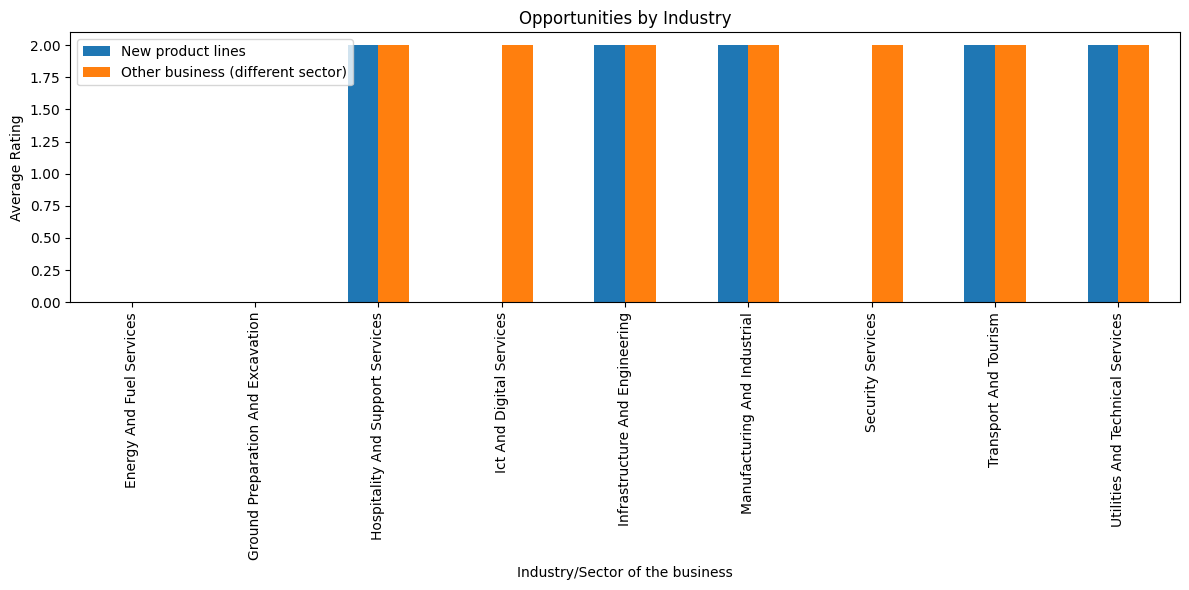

,New product lines,Other business (different sector)
Location:,,
Amandelbult,2.0,2.0
Mogalakwena,2.0,2.0
Polokwane,2.0,2.0
Rustenburg,2.0,2.0


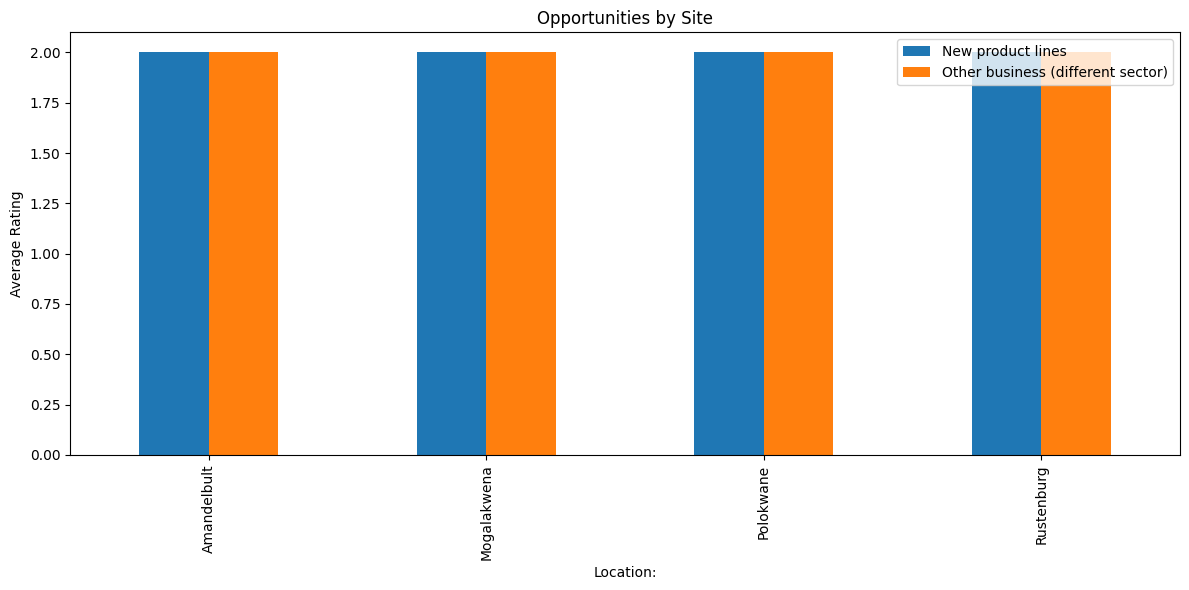


🔹 THREATS CLUSTER


,Loss of largest customer,Ease of entry into new market,Change in technology,Changing customer preferrences
Industry/Sector of the business,,,,
Energy And Fuel Services,NaN,2.0,2.0,NaN
Ground Preparation And Excavation,2.0,2.0,2.0,2.0
Hospitality And Support Services,2.0,2.0,2.0,2.0
Ict And Digital Services,NaN,NaN,NaN,NaN
Infrastructure And Engineering,2.0,2.0,2.0,2.0
Manufacturing And Industrial,2.0,2.0,2.0,2.0
Security Services,NaN,2.0,2.0,2.0
Transport And Tourism,2.0,2.0,2.0,2.0
Utilities And Technical Services,2.0,2.0,2.0,2.0


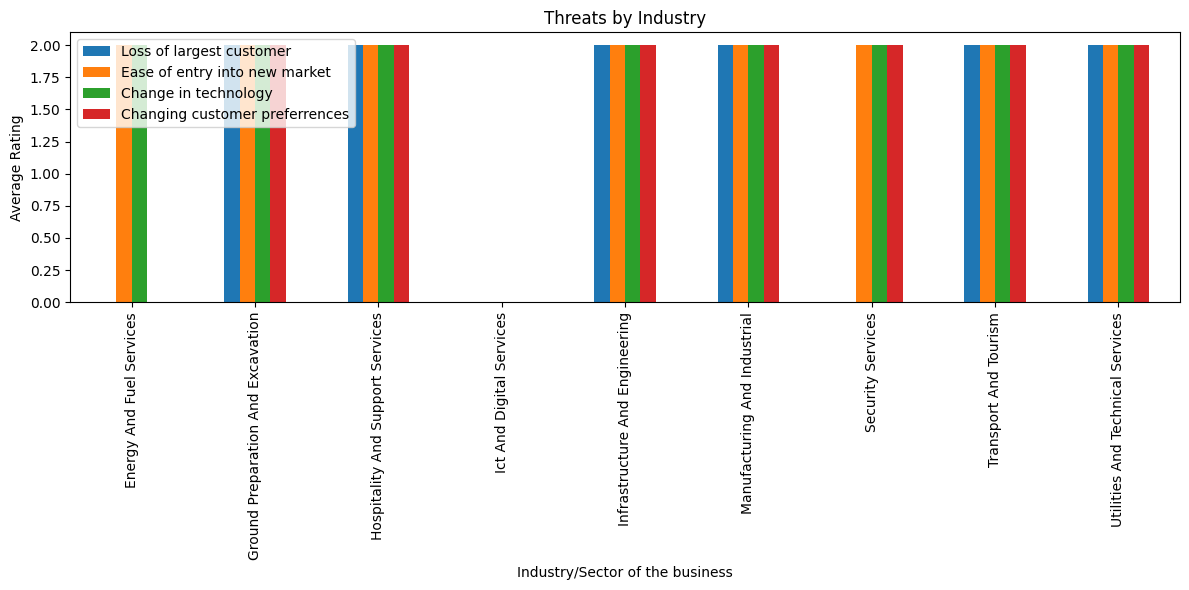

,Loss of largest customer,Ease of entry into new market,Change in technology,Changing customer preferrences
Location:,,,,
Amandelbult,2.0,2.0,2.0,2.0
Mogalakwena,2.0,2.0,2.0,2.0
Polokwane,2.0,2.0,2.0,2.0
Rustenburg,2.0,2.0,2.0,2.0


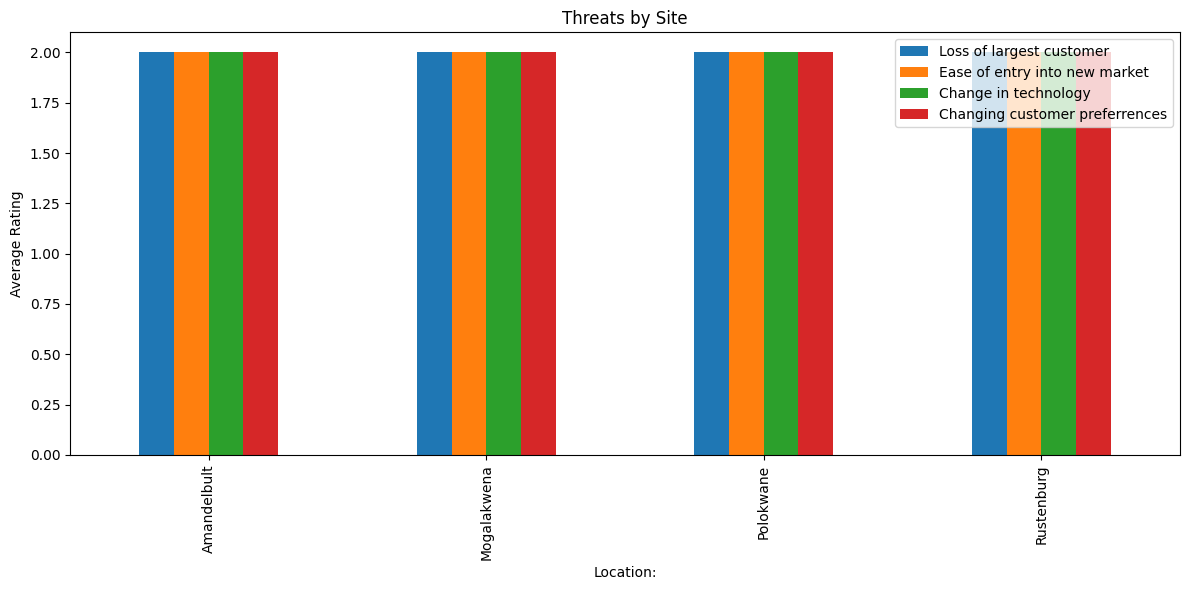

In [ ]:
# @title SECTION 2: Business Efficiencies and Capabilities

# --- Define the clusters and rating mapping ---
clusters = {
    'Strengths': ['Good Systems', 'Strong Cashflow', 'Expert Skills', 'Unique product or service'],
    'Weaknesses': ['Lack of funding', 'Lack of tenders', 'High Staff turnover', 'Stiff market competition', 'Alternative products/services in the market'],
    'Opportunities': ['New product lines', 'Other business (different sector)'],
    'Threats': ['Loss of largest customer', 'Ease of entry into new market', 'Change in technology', 'Changing customer preferrences']
}

rating_map = {
    'Very Weak': 0,
    'Weak': 1,
    'Moderate': 2,
    'Strong': 3,
    'Very Strong': 4
}

# --- Helper function to convert ratings ---
def map_ratings(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().map(rating_map)
    return df

# --- Analyze clusters ---
def analyze_clusters(df, clusters):
    for cluster, cols in clusters.items():
        print(f"\n🔹 {cluster.upper()} CLUSTER")
        df_copy = df[['Industry/Sector of the business', 'Location:'] + cols].copy()
        df_copy = map_ratings(df_copy, cols)

        # By Industry
        industry_summary = df_copy.groupby('Industry/Sector of the business')[cols].mean().round(2)
        display(industry_summary)
        if not industry_summary.empty:
            industry_summary.plot(kind='bar', figsize=(12, 6), title=f"{cluster} by Industry")
            plt.ylabel("Average Rating")
            plt.tight_layout()
            plt.show()

        # By Site
        site_summary = df_copy.groupby('Location:')[cols].mean().round(2)
        display(site_summary)
        if not site_summary.empty:
            site_summary.plot(kind='bar', figsize=(12, 6), title=f"{cluster} by Site")
            plt.ylabel("Average Rating")
            plt.tight_layout()
            plt.show()

# --- Skills Gaps ---
skills_columns = {
    "Financial Management": "Financial Management",
    "Business Management": "Business Management",
    "Marketing and Sales": "Marketing and Sales2",
    "Human Resources": "Human Resources",
    "Customer Service": "Customer Services",
    "Regulatory & Compliance": "Regulatory and Compliance",
    "Supply Chain & Procurement": "Supply Chain (procurement)",
    "Project Management": "Project Management"
}

yes_vals = ['yes', 'y', '✔', '✓', 'true', '1']
no_vals = ['no', 'n', '✘', '✕', 'false', '0']

skills_df = df[['Location:'] + list(skills_columns.values())].copy()
for col in skills_columns.values():
    skills_df[col] = skills_df[col].astype(str).str.strip().str.lower()
    skills_df[col] = skills_df[col].apply(lambda x: 1 if x in yes_vals else 0 if x in no_vals else pd.NA)

# Aggregate skills gap
skills_gap_pct = 100 - skills_df[skills_columns.values()].mean().multiply(100).round(1)
skills_gap_pct.index = list(skills_columns.keys())
print("📊 Aggregate Skills Gaps (% SMEs with reported gap):")
display(skills_gap_pct)

# Site-specific
site_gap_pct = 100 - skills_df.groupby('Location:')[list(skills_columns.values())].mean().multiply(100).round(1)
site_gap_pct.columns = list(skills_columns.keys())
print("📍 Site-Specific Skills Gaps (% SMEs with reported gap):")
display(site_gap_pct)

# Plot heatmap
# Ensure numeric and clean data for plotting
site_gap_clean = site_gap_pct.apply(pd.to_numeric, errors='coerce')  # Force numeric conversion
site_gap_clean = site_gap_clean.dropna(how='all')  # Drop rows where all values are NaN
site_gap_clean = site_gap_clean.dropna(axis=1, how='all')  # Drop columns where all values are NaN

if not site_gap_clean.empty:
    plt.figure(figsize=(12, max(4, len(site_gap_clean) * 0.6)))
    sns.heatmap(site_gap_clean, annot=True, fmt=".1f", cmap="YlOrBr", linewidths=0.5)
    plt.title("Skills Gaps by Site (% SMEs reporting gap)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid numeric data available to display in heatmap.")


# Run cluster analysis
analyze_clusters(df, clusters)


📊 Aggregate Average Skills Gaps (0 = No Gap, 4 = Serious Gap):


,0
Financial Management,2.56
Marketing and Sales,2.31
Human Resources,2.22
Supply Chain & Procurement,1.97
Business Management,1.91
Project Management,1.64
Customer Service,1.61
Regulatory & Compliance,1.45


📍 Site-Specific Average Skills Gaps:


,Financial Management,Business Management,Marketing and Sales,Human Resources,Customer Service,Regulatory & Compliance,Supply Chain & Procurement,Project Management
Location:,,,,,,,,
Amandelbult,2.50,1.64,2.21,2.29,1.43,1.86,2.36,1.71
Mogalakwena,2.37,1.67,2.22,2.15,1.52,1.07,1.67,1.56
Polokwane,3.11,2.22,2.11,2.22,1.56,1.67,1.67,1.56
Rustenburg,2.64,2.43,2.71,2.29,2.00,1.64,2.36,1.79


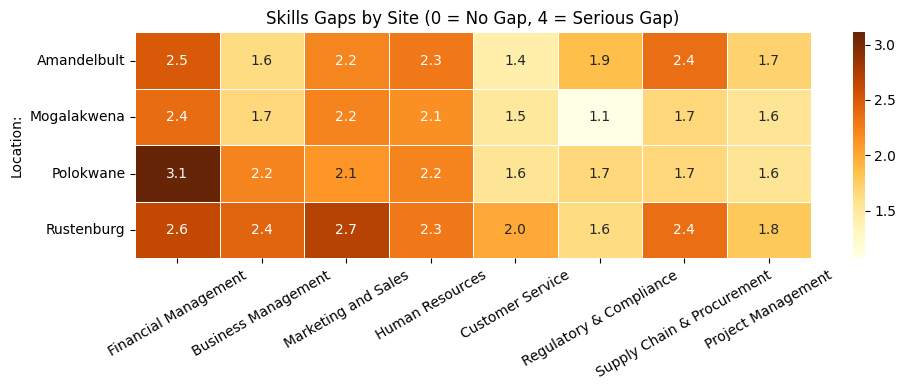

In [ ]:
# @title SECTION 3: Skills and Capabilities (Corrected)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define skill column labels (from your Excel sheet)
skills_columns = {
    "Financial Management": "Financial Management",
    "Business Management": "Business Management",
    "Marketing and Sales": "Marketing and Sales2",
    "Human Resources": "Human Resources",
    "Customer Service": "Customer Services",
    "Regulatory & Compliance": "Regulatory and Compliance",
    "Supply Chain & Procurement": "Supply Chain (procurement)",
    "Project Management": "Project Management"
}

# Map categorical skill gap responses to numeric values
gap_scale = {
    'no gap': 0,
    'negligible gap': 1,
    'moderate': 2,
    'identified gap': 3,
    'serious gap': 4
}

# Select relevant columns from the dataset
skills_df = df[['Location:'] + list(skills_columns.values())].copy()

# Normalize and convert skill gap categories to numeric
for col in skills_columns.values():
    skills_df[col] = skills_df[col].astype(str).str.strip().str.lower().map(gap_scale)

# --- Aggregate: Average skill gap levels across all SMEs ---
skills_gap_avg = skills_df[skills_columns.values()].mean().round(2)
skills_gap_avg.index = list(skills_columns.keys())

print("📊 Aggregate Average Skills Gaps (0 = No Gap, 4 = Serious Gap):")
display(skills_gap_avg.sort_values(ascending=False))

# --- Site-specific analysis ---
site_gap_avg = skills_df.groupby('Location:')[list(skills_columns.values())].mean().round(2)
site_gap_avg.columns = list(skills_columns.keys())

print("📍 Site-Specific Average Skills Gaps:")
display(site_gap_avg)

# --- Clean and plot heatmap ---
site_gap_clean = site_gap_avg.apply(pd.to_numeric, errors='coerce').dropna(how='all').dropna(axis=1, how='all')

if not site_gap_clean.empty:
    plt.figure(figsize=(10, max(4, len(site_gap_clean) * 0.6)))
    sns.heatmap(site_gap_clean, annot=True, fmt=".1f", cmap="YlOrBr", linewidths=0.5)
    plt.title("Skills Gaps by Site (0 = No Gap, 4 = Serious Gap)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid numeric data to display in heatmap.")


📊 Average Product Share by Site:


,Top Product %,Second Product %,Third Product %
Location,,,
Amandelbult,0.71,0.17,0.08
Mogalakwena,19.26,37.18,18.65
Polokwane,0.90,0.08,0.02
Rustenburg,0.87,0.14,0.03


💰 Total Non-Mining Revenue by Site:


,Non-Mining Revenue
Location,
Mogalakwena,42232240.00
Amandelbult,9700413.10
Polokwane,9127368.00
Rustenburg,3823804.72


🌍 Sales Distribution by Location (%):


Sales Location,In another province,Nationwide,Nearby town,Same town
Location,,,,
Amandelbult,7.1,0.0,35.7,57.1
Mogalakwena,0.0,14.8,25.9,59.3
Polokwane,11.1,33.3,33.3,22.2
Rustenburg,14.3,0.0,14.3,71.4


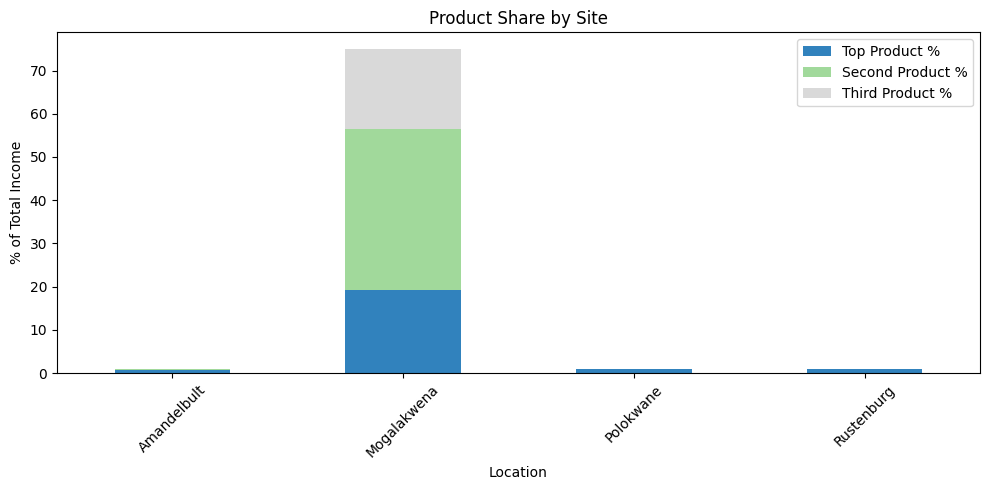

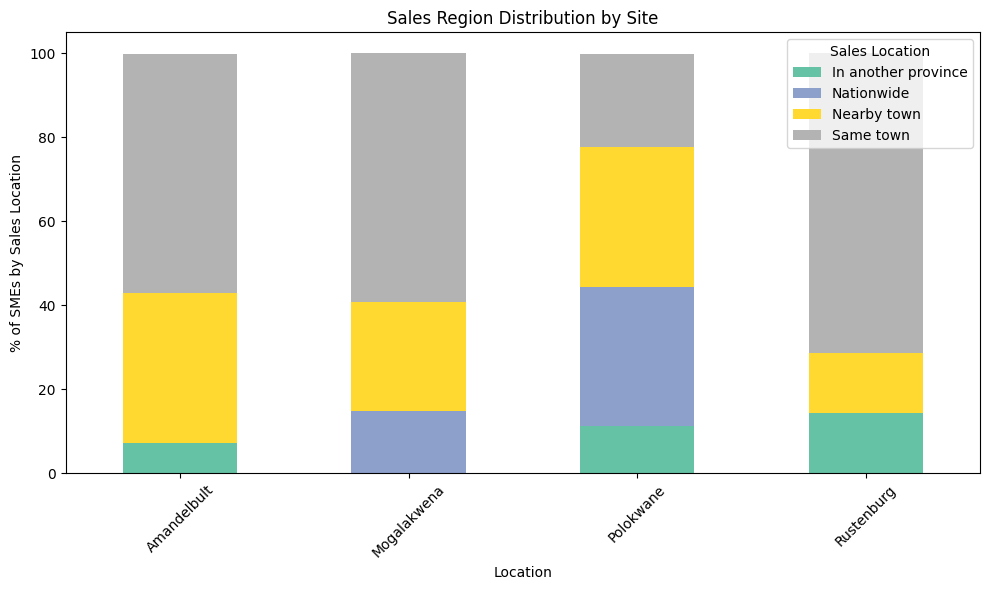

👥 Example Customer Info (First 5):


,Location,Customer Info
0,Mogalakwena,Mogalakwena mine
1,Mogalakwena,Mogalakwena Mine
2,Polokwane,Anglo American Platinum (6712427) Lebalelo Wat...
3,Rustenburg,Alarm & Security Partner 1536243
4,Amandelbult,NON


In [ ]:
# @title SECTION 4: Product and Service Range

# Define relevant columns
product_cols = {
    'Location': 'Location:',
    'Main Product': 'What is your mainline product or service?',
    'Top Product %': 'What is the percentage of the top sales product/service as a fraction of the total income?',
    'Second Product %': 'What is the percentage of the second best product/service as a fraction of the total income?',
    'Third Product %': 'What is the percentage of the third best product/service as a fraction of the total income?',
    'Customer Info': 'List your 3 main customers and how much did you sell to them last FY? example Anglo American (350000) Royal Bafokeng (1000000) Matsatsi (500000)',
    'Non-Mining Revenue': 'What is the total revenue from non-mining sales for the most recent financial year end?',
    'Sales Location': 'Where do you sell most of your products/services?'
}

# Load and prepare data
ps_df = df[list(product_cols.values())].copy()
ps_df.rename(columns={v: k for k, v in product_cols.items()}, inplace=True)

# Convert income % fields to numeric
income_cols = ['Top Product %', 'Second Product %', 'Third Product %']
for col in income_cols + ['Non-Mining Revenue']:
    ps_df[col] = pd.to_numeric(ps_df[col], errors='coerce')

# --- Aggregate Product Share by Site ---
site_summary = ps_df.groupby('Location')[income_cols].mean().round(2)
print("📊 Average Product Share by Site:")
display(site_summary)

# --- Revenue Diversification from Non-Mining ---
nmining_summary = ps_df.groupby('Location')['Non-Mining Revenue'].sum().sort_values(ascending=False)
print("💰 Total Non-Mining Revenue by Site:")
display(nmining_summary)

# --- Add Non-Mining % (Approximate to Top + Second + Third) ---
ps_df['Total Income %'] = ps_df[income_cols].sum(axis=1)
ps_df['Non-Mining % of Income'] = ((ps_df['Non-Mining Revenue'] / ps_df['Non-Mining Revenue'].max()) * 100).round(1)

# --- Sales Location Distribution ---
sales_loc_dist = ps_df.groupby(['Location', 'Sales Location']).size().unstack(fill_value=0)
sales_loc_pct = sales_loc_dist.div(sales_loc_dist.sum(axis=1), axis=0).multiply(100).round(1)
print("🌍 Sales Distribution by Location (%):")
display(sales_loc_pct)

# --- Plots ---
site_summary.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20c', title="Product Share by Site")
plt.ylabel("% of Total Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sales_loc_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', title="Sales Region Distribution by Site")
plt.ylabel("% of SMEs by Sales Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Optional: Display sample customer info (summarised) ---
print("👥 Example Customer Info (First 5):")
display(ps_df[['Location', 'Customer Info']].dropna().head())


📊 Aggregate Diversification Indicators (% SMEs):


,0
Ready Market,89.1
Sales Plan,67.2
New Product Plan,45.3
Market Research,39.1
New Markets,31.2
Started Venture,29.7
Business Plan,25.0
Financial Resources,14.1


📍 Diversification Indicators by Site (% SMEs):


,Market Research,New Markets,Sales Plan,New Product Plan,Started Venture,Financial Resources,Business Plan,Ready Market
Location:,,,,,,,,
Amandelbult,28.6,21.4,64.3,35.7,50.0,0.0,35.7,92.9
Mogalakwena,48.1,33.3,70.4,63.0,22.2,7.4,22.2,85.2
Polokwane,33.3,44.4,77.8,33.3,22.2,33.3,11.1,88.9
Rustenburg,35.7,28.6,57.1,28.6,28.6,28.6,28.6,92.9


<Figure size 1000x600 with 0 Axes>

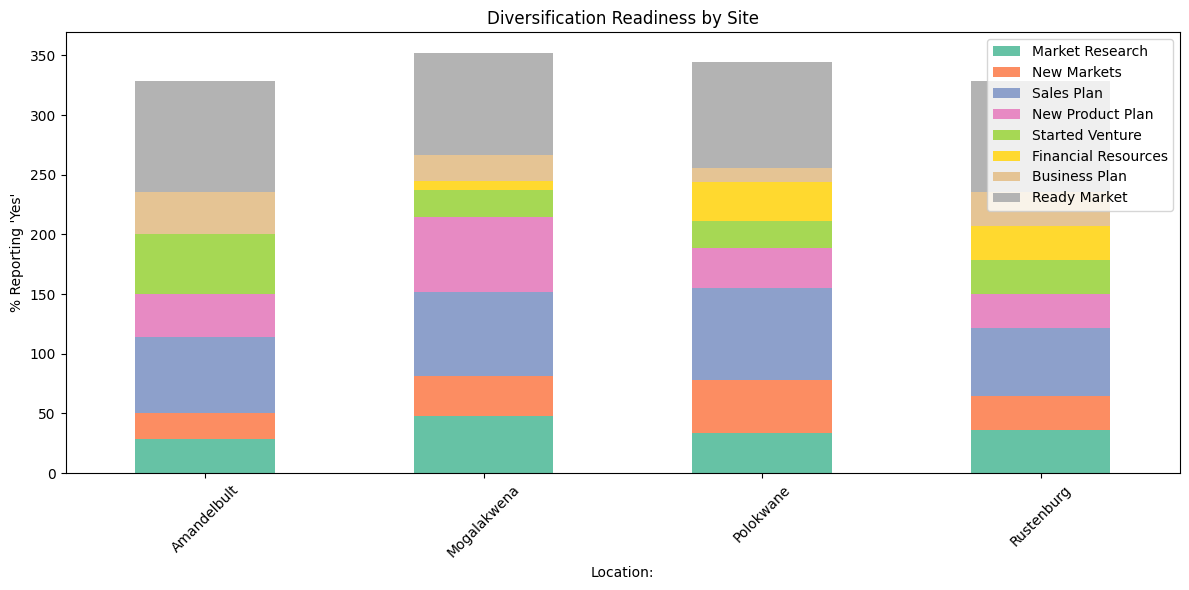


📝 New Product Details Themes for Amandelbult: ['transportation', 'business', 'truck', 'current', 'cement', 'surveillance', 'systems', 'thabazimbi', 'section', 'repair']

📝 New Product Details Themes for Mogalakwena: ['supply', 'sharing', 'training', 'planning', 'concrete', 'wants', 'print', 'allow', 'business', 'service']

📝 New Product Details Themes for Polokwane: ['services', 'welding', 'repairs', 'structural', 'maintenance', 'coding', 'training', 'technicians', 'started', 'strip']

📝 New Product Details Themes for Rustenburg: ['services', 'process', 'supply', 'business', 'management', 'cleaning', 'meals', 'products', 'steel', 'other']

📝 Support Required Themes for Amandelbult: ['funding', 'market', 'linkages', 'equipment']

📝 Support Required Themes for Mogalakwena: ['funding', 'market', 'linkages', 'equipment', 'training']

📝 Support Required Themes for Polokwane: ['funding', 'market', 'linkages', 'training']

📝 Support Required Themes for Rustenburg: ['market', 'linkages', 'equ

{'Amandelbult': [('access', 12),
  ('funding', 10),
  ('market', 2),
  ('technology', 2)],
 'Mogalakwena': [('access', 25),
  ('funding', 16),
  ('market', 9),
  ('skills', 2)],
 'Polokwane': [('access', 6), ('funding', 4), ('skills', 3), ('market', 2)],
 'Rustenburg': [('access', 13),
  ('market', 10),
  ('funding', 3),
  ('competition', 1)]}

In [ ]:
# @title SECTION 5: Tracking for Diversification

# Define relevant column mappings
div_cols = {
    "Market Research": "Has the SME conducted a market assessment or research in the last 6 months?",
    "New Markets": "Have you accessed new markets in the past 12 months?",
    "New Market Specified": "If yes, please specify the new market entered:",
    "Sales Plan": "Does the SME have a sales plan or value proposition in place?",
    "New Product Plan": "Does the business plan to introduce new products/services in the next 12 months?",
    "New Product Details": "What are your planned \"new\" products or services?",
    "Started Venture": "Have you started on this venture yet?",
    "Financial Resources": "Do you have financial resources available for expansion?",
    "Amount Invested": "How much have you invested in the venture so far?",
    "Business Plan": "Have you prepared a business plan already?",
    "Ready Market": "Is there a ready market for the product/service?",
    "Clients": "Who would be the biggest clients for this product or service?",
    "Time to Establish": "How many months would it take to establish this venture?",
    "Challenges": "What challenges/barriers have you identified so far with this venture? choose all relevant",
    "Support Required": "What support do you require for this business idea?",
}

# Create working DataFrame
div_df = df[['Location:'] + list(div_cols.values())].copy()

# Normalize Yes/No responses
yes_vals = ['yes', 'y', '✔', '✓', 'true', '1']
def normalize_binary(col):
    return col.astype(str).str.strip().str.lower().apply(lambda x: 1 if x in yes_vals else 0)

quantitative_fields = [
    "Market Research", "New Markets", "Sales Plan", "New Product Plan",
    "Started Venture", "Financial Resources", "Business Plan", "Ready Market"
]

# Apply normalization
for field in quantitative_fields:
    div_df[field] = normalize_binary(div_df[div_cols[field]])

# --- Aggregate Data ---
agg_pct = div_df[quantitative_fields].mean().multiply(100).round(1).sort_values(ascending=False)
print("📊 Aggregate Diversification Indicators (% SMEs):")
display(agg_pct)

# --- Site-specific Data ---
site_pct = div_df.groupby('Location:')[quantitative_fields].mean().multiply(100).round(1)
print("📍 Diversification Indicators by Site (% SMEs):")
display(site_pct)

# --- Visualization ---
plt.figure(figsize=(10, 6))
site_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 6))
plt.title("Diversification Readiness by Site")
plt.ylabel("% Reporting 'Yes'")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Thematic Analysis Function ---
def thematic_analysis(col_key):
    column = div_cols[col_key]
    results = {}
    for site, group in div_df.groupby("Location:"):
        text = ' '.join(group[column].dropna().astype(str))
        blob = TextBlob(text)
        keywords = [w.lower() for w in blob.words if len(w) > 4]
        themes = Counter(keywords).most_common(10)
        results[site] = themes
        print(f"\n📝 {col_key} Themes for {site}: {[kw for kw, _ in themes]}")
    return results

# Run Thematic Analysis
thematic_analysis("New Product Details")
thematic_analysis("Support Required")
thematic_analysis("Challenges")


📊 Aggregated Partnership Indicators by Site (% or Avg Number):


,Engaged,Signed Agreements,Interested
Location,,,
Amandelbult,71.0,14.0,88.888889
Mogalakwena,104.0,11.0,84.0
Polokwane,89.0,22.0,85.714286
Rustenburg,79.0,29.0,100.0


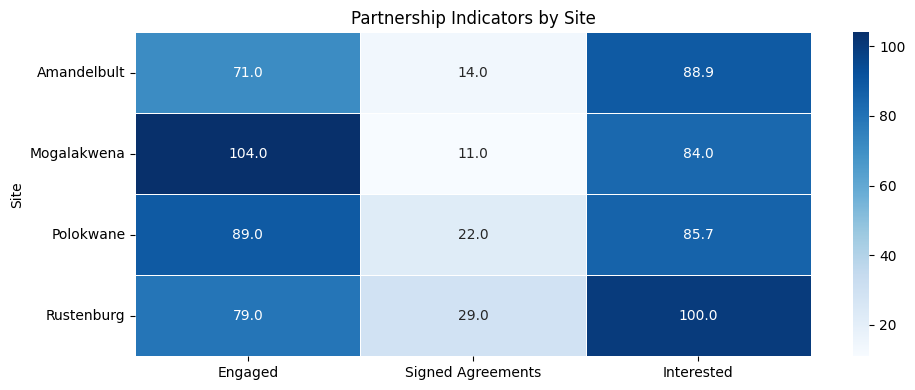

📌 Partnership Types by Site (Reported Counts):


Types,"Joint Venture (resource pooling, risk sharing, project specific)","Collaborative (Research and Development, Marketing, disctribution, supply chain enhancement)",Market Access,Supply integrations (supply chain of larger company),"Technology sharing (product improvement, quality, customer engagement)",none
Location,,,,,,
Amandelbult,2,0,3,0,1,8
Mogalakwena,4,5,7,2,1,8
Polokwane,1,0,2,2,0,4
Rustenburg,1,0,4,0,2,7


In [ ]:
# @title SECTION 6: Partnerships

# Define relevant column names from Excel
partnership_columns = {
    "Engaged": "How many partnerships has the SME engaged for business growth",
    "Types": "Select the most relevant type(s) of partnerships engaged:",
    "Signed Agreements": "Is there a signed agreement in place for the partnership?",
    "Interested": "If no partnership in place, does the SME have interest in partnerships to grow the business?"
}

# Normalize column names
df.columns = df.columns.str.strip()

# Extract relevant data
partnership_df = df[['Location:'] + list(partnership_columns.values())].copy()
partnership_df.columns = ['Location'] + list(partnership_columns.keys())

# Normalize Yes/No fields
yes_vals = ['yes', 'y', '✔', '✓', 'true', '1']
no_vals = ['no', 'n', '✘', '✕', 'false', '0']

for col in ['Signed Agreements', 'Interested']:
    partnership_df[col] = partnership_df[col].astype(str).str.lower().str.strip()
    partnership_df[col] = partnership_df[col].apply(lambda x: 1 if x in yes_vals else 0 if x in no_vals else pd.NA)

# --- Aggregated metrics by site ---
agg_partnerships = partnership_df.groupby('Location').agg({
    'Engaged': 'mean',
    'Signed Agreements': 'mean',
    'Interested': 'mean'
}).round(2) * 100

print("📊 Aggregated Partnership Indicators by Site (% or Avg Number):")
display(agg_partnerships)

# --- Plot heatmap ---
# --- Clean and plot heatmap ---
agg_partnerships_clean = agg_partnerships.apply(pd.to_numeric, errors='coerce')  # Ensure all values are numeric
agg_partnerships_clean = agg_partnerships_clean.dropna(how='all')  # Drop rows with all NaNs
agg_partnerships_clean = agg_partnerships_clean.dropna(axis=1, how='all')  # Drop columns with all NaNs

if not agg_partnerships_clean.empty:
    plt.figure(figsize=(10, max(4, len(agg_partnerships_clean) * 0.6)))
    sns.heatmap(agg_partnerships_clean, annot=True, cmap='Blues', fmt=".1f", linewidths=0.5)
    plt.title("Partnership Indicators by Site")
    plt.ylabel("Site")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid numeric data to display in heatmap.")

# --- Types of partnerships (count per site) ---
types_by_site = partnership_df.groupby('Location')['Types'].value_counts().unstack(fill_value=0)

print("📌 Partnership Types by Site (Reported Counts):")
display(types_by_site)


# INDICATORS FROM LOGFRAME WORK

In [ ]:
# @title calculate logframe indicator values from the baseline tool

import pandas as pd

# Load and clean dataset
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Sample indicators calculated from the cleaned DataFrame

# 1. % SMEs with Net Profit (assume 'npat' or similar exists)
if 'npat' in df.columns:
    net_profit_pct = (df['npat'] > 0).mean() * 100
else:
    net_profit_pct = None

# 2. % SMEs with multiple income streams (assume columns like 'product_2_pct', 'product_3_pct')
product_cols = [col for col in df.columns if 'product' in col and '_pct' in col]
multi_income_pct = (df[product_cols].fillna(0).gt(0).sum(axis=1) > 1).mean() * 100

# 3. % with business plans (assume 'business_plan' is binary or yes/no)
bp_col = [col for col in df.columns if 'business_plan' in col]
if bp_col:
    business_plan_pct = (df[bp_col[0]].astype(str).str.lower().isin(['yes', '1', 'true'])).mean() * 100
else:
    business_plan_pct = None

# 4. % with sales plans
sales_plan_col = [col for col in df.columns if 'sales_plan' in col]
if sales_plan_col:
    sales_plan_pct = (df[sales_plan_col[0]].astype(str).str.lower().isin(['yes', '1', 'true'])).mean() * 100
else:
    sales_plan_pct = None

# 5. % engaged in partnerships (assume 'partnership_engaged' column exists)
partnership_col = [col for col in df.columns if 'engaged' in col or 'partnership' in col]
if partnership_col:
    partnership_pct = (df[partnership_col[0]].astype(str).str.lower().isin(['yes', '1', 'true'])).mean() * 100
else:
    partnership_pct = None

# 6. % accessing new markets (assume 'new_market' column)
market_col = [col for col in df.columns if 'new_market' in col]
if market_col:
    new_market_pct = (df[market_col[0]].astype(str).str.lower().isin(['yes', '1', 'true'])).mean() * 100
else:
    new_market_pct = None

# 7. Avg # partnerships per SME (assume partnership count fields exist)
partnership_count_cols = [col for col in df.columns if 'partnership_' in col and 'count' in col]
if partnership_count_cols:
    avg_partnerships = df[partnership_count_cols].fillna(0).sum(axis=1).mean()
else:
    avg_partnerships = None

# 8. Avg financial skills gap (e.g., 'skills_financial_management')
skills_col = [col for col in df.columns if 'financial' in col and 'skills' in col]
if skills_col:
    avg_fin_skills_gap = df[skills_col[0]].mean()
else:
    avg_fin_skills_gap = None

# 9. % ready to diversify (e.g., ready_market + new_product_plan)
div_ready_cols = [col for col in df.columns if 'ready_market' in col or 'new_product_plan' in col]
if div_ready_cols:
    div_ready_pct = (df[div_ready_cols].apply(lambda row: any(str(val).lower() in ['yes', '1', 'true'] for val in row), axis=1)).mean() * 100
else:
    div_ready_pct = None

# Compile results
results = {
    "% SMEs reporting Net Profit": net_profit_pct,
    "% SMEs with diversified income streams": multi_income_pct,
    "% SMEs with business plans": business_plan_pct,
    "% SMEs with sales plans": sales_plan_pct,
    "% SMEs in partnerships": partnership_pct,
    "% SMEs in new markets": new_market_pct,
    "Avg. # of partnerships per SME": avg_partnerships,
    "Avg. financial skills gap": avg_fin_skills_gap,
    "% SMEs ready to diversify": div_ready_pct
}

# Convert to DataFrame for display
indicator_df = pd.DataFrame(list(results.items()), columns=["Indicator", "Value (%) or Avg."])
indicator_df


,Indicator,Value (%) or Avg.
0,% SMEs reporting Net Profit,89.0625
1,% SMEs with diversified income streams,0.0000
2,% SMEs with business plans,45.3125
3,% SMEs with sales plans,67.1875
4,% SMEs in partnerships,29.6875
5,% SMEs in new markets,0.0000
6,Avg. # of partnerships per SME,NaN
7,Avg. financial skills gap,NaN
8,% SMEs ready to diversify,89.0625


In [ ]:
import pandas as pd

df.columns = df.columns.str.strip().str.lower().str.replace(":", "").str.replace("?", "").str.replace(" ", "_")

# Initialize indicator dictionary
indicators = {}

# Helper: Clean yes/no responses
def is_yes(x):
    return str(x).strip().lower() in ['yes', 'y', 'true', '1']

# 1. % of SMEs reporting Net Profit (NPAT) over the reporting period
npat_col = 'state_the_2024_npat_as_a_number'
if npat_col in df.columns:
    indicators['% SMEs reporting NPAT 2024'] = df[npat_col].apply(lambda x: pd.to_numeric(x, errors='coerce') > 0).mean() * 100

# 2. % of SMEs with diversified revenue streams (Top product < 70%)
top_prod_col = 'what_is_the_percentage_of_the_top_sales_product/service_as_a_fraction_of_the_total_income'
if top_prod_col in df.columns:
    indicators['% SMEs with diversified revenue streams (<70%)'] = df[top_prod_col].apply(lambda x: pd.to_numeric(x, errors='coerce') < 70).mean() * 100

# 3. Number of at-risk jobs retained (sum)
female_risk = 'how_many_female_jobs_within_the_business_do_you_consider_to_be_at_risk_due_to_economic_changes_particularly_those_related_to_the_mining_industry'
male_risk = 'how_many_male_jobs_within_the_business_do_you_consider_to_be_at_risk_due_to_economic_changes_particularly_those_related_to_the_mining_industry'
if female_risk in df.columns and male_risk in df.columns:
    indicators['Total at-risk jobs reported'] = df[[female_risk, male_risk]].fillna(0).sum().sum()

# 4. % of SMEs accessing new customers/markets
market_access_col = 'have_you_accessed_new_markets_in_the_past_12_months'
if market_access_col in df.columns:
    indicators['% SMEs accessing new markets (last 12 mo)'] = df[market_access_col].apply(is_yes).mean() * 100

# 5. % of SMEs launching new products/services
new_prod_col = 'does_the_business_plan_to_introduce_new_products/services_in_the_next_12_months'
if new_prod_col in df.columns:
    indicators['% SMEs planning to launch new product/service'] = df[new_prod_col].apply(is_yes).mean() * 100

# 6. # SMEs with ready market for new product
ready_market_col = 'is_there_a_ready_market_for_the_product/service'
if ready_market_col in df.columns:
    indicators['# SMEs with ready market identified'] = df[ready_market_col].apply(is_yes).sum()

# 7. # new products/services already started
started_venture_col = 'have_you_started_on_this_venture_yet'
if started_venture_col in df.columns:
    indicators['# SMEs that started new venture'] = df[started_venture_col].apply(is_yes).sum()

# 8. # partnerships engaged
partnerships_col = 'how_many_partnerships_has_the_sme_engaged_for_business_growth'
if partnerships_col in df.columns:
    indicators['Avg. # of partnerships engaged'] = pd.to_numeric(df[partnerships_col], errors='coerce').fillna(0).mean()

# 9. # signed partnership agreements
signed_col = 'is_there_a_signed_agreement_in_place_for_the_partnership'
if signed_col in df.columns:
    indicators['# SMEs with signed partnership agreements'] = df[signed_col].apply(is_yes).sum()

# 10. % of SMEs with business plans
bp_col = 'have_you_prepared_a_business_plan_already'
if bp_col in df.columns:
    indicators['% SMEs with business plans'] = df[bp_col].apply(is_yes).mean() * 100

# Compile results into a DataFrame
indicator_df = pd.DataFrame.from_dict(indicators, orient='index', columns=['Value'])
indicator_df = indicator_df.round(2)  # Round for clarity

# Display
indicator_df.reset_index().rename(columns={'index': 'Indicator'})


,Indicator,Value
0,% SMEs reporting NPAT 2024,79.69
1,% SMEs with diversified revenue streams (<70%),98.44
2,% SMEs accessing new markets (last 12 mo),31.25
3,% SMEs planning to launch new product/service,45.31
4,# SMEs with ready market identified,57.00
5,# SMEs that started new venture,19.00
6,Avg. # of partnerships engaged,0.89
7,# SMEs with signed partnership agreements,11.00
8,% SMEs with business plans,25.00


In [ ]:
# CONTINUING FROM PREVIOUS BLOCK
# These new indicators are added to the existing `indicators` dictionary

# 11. Number of jobs supported (total full-time + part-time)
perm_female = 'how_many_permanent_(full_time)_female_employees_does_the_business_have'
perm_male = 'how_many_permanent_(full_time)_male_employees_does_the_business_have'
temp_female = 'how_many_temporary_(part_time)_female_employees_does_the_business_have'
temp_male = 'how_many_temporary_(part_time)_male_employees_does_the_business_have'
if all(col in df.columns for col in [perm_female, perm_male, temp_female, temp_male]):
    df_jobs = df[[perm_female, perm_male, temp_female, temp_male]].apply(pd.to_numeric, errors='coerce').fillna(0)
    indicators["# Jobs supported (perm + temp)"] = df_jobs.sum(axis=1).sum()

# 12. % of SMEs using financial practices (budgeting, statements, accounting software)
practices_cols = [
    'do_you_prepare_budgets_annually',
    'do_you_prepare_financial_statements_annually',
    'do_you_use_an_accounting_software'
]
if all(col in df.columns for col in practices_cols):
    indicators['% SMEs using financial practices'] = df[practices_cols].applymap(is_yes).mean(axis=1).gt(0.66).mean() * 100

# 13. # SMEs with formal business plans AND finance systems
if all(col in df.columns for col in [bp_col, 'do_you_use_an_accounting_software']):
    indicators['# SMEs with business plan + accounting system'] = (
        df[bp_col].apply(is_yes) & df['do_you_use_an_accounting_software'].apply(is_yes)
    ).sum()

# 14. % of SMEs with customer retention plan (based on open-text presence)
cust_ret_col = 'what_is_the_sme_doing_to_attract_and_retain_customers'
if cust_ret_col in df.columns:
    indicators['% SMEs with customer retention plan (text present)'] = df[cust_ret_col].notna().mean() * 100

# 15. % of SMEs that accessed training/workshops/mentorship
event_cols = [
    'has_the_sme_(representative/owner)_attended_any_networking_events_in_the_past_year',
    'has_the_sme_(representative/owner)_attended_any_bootcamps/workshops/clinics_in_the_past_year',
    'has_the_sme_gone_through_any_business_mentoring_program_before'
]
if all(col in df.columns for col in event_cols):
    indicators['% SMEs participated in training/mentorship'] = df[event_cols].applymap(is_yes).any(axis=1).mean() * 100

# 16. % SMEs with >15% revenue increase from 2022–2024
rev_2022 = 'state_the_annual_turnover_for_2022_as_a_number/amount'
rev_2024 = 'state_the_annual_turnover_for_2024_as_a_number/amount'
if all(col in df.columns for col in [rev_2022, rev_2024]):
    rev_growth = (
        pd.to_numeric(df[rev_2024], errors='coerce') - pd.to_numeric(df[rev_2022], errors='coerce')
    ) / pd.to_numeric(df[rev_2022], errors='coerce')
    indicators['% SMEs with >15% revenue growth (2022–24)'] = rev_growth.gt(0.15).mean() * 100

# 17. % of SMEs with value propositions
val_prop_col = 'if_"yes"_to_the_above,_kindly_state_the_number_of_value_propositions'
if val_prop_col in df.columns:
    indicators['% SMEs with ≥1 value proposition'] = pd.to_numeric(df[val_prop_col], errors='coerce').fillna(0).gt(0).mean() * 100

# 18. % of SMEs with financial resources for growth
res_col = 'do_you_have_financial_resources_available_for_expansion'
if res_col in df.columns:
    indicators['% SMEs with financial resources for expansion'] = df[res_col].apply(is_yes).mean() * 100

# --- Final indicator display ---
final_df = pd.DataFrame.from_dict(indicators, orient='index', columns=['Value']).round(2)
final_df.reset_index().rename(columns={'index': 'Indicator'})


<ipython-input-90-92bfe8f17343>:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  indicators['% SMEs using financial practices'] = df[practices_cols].applymap(is_yes).mean(axis=1).gt(0.66).mean() * 100
<ipython-input-90-92bfe8f17343>:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  indicators['% SMEs participated in training/mentorship'] = df[event_cols].applymap(is_yes).any(axis=1).mean() * 100


,Indicator,Value
0,% SMEs reporting NPAT 2024,79.69
1,% SMEs with diversified revenue streams (<70%),98.44
2,% SMEs accessing new markets (last 12 mo),31.25
3,% SMEs planning to launch new product/service,45.31
4,# SMEs with ready market identified,57.00
5,# SMEs that started new venture,19.00
6,Avg. # of partnerships engaged,0.89
7,# SMEs with signed partnership agreements,11.00
8,% SMEs with business plans,25.00
9,% SMEs using financial practices,39.06


In [ ]:
# CONTINUED from previous blocks
# Using the same df and indicators dictionary

# 19. % of SMEs that report using growth/development plans
growth_plan_col = 'have_you_prepared_a_business_plan_already'
if growth_plan_col in df.columns:
    indicators['% SMEs following a growth/development plan'] = df[growth_plan_col].apply(is_yes).mean() * 100

# 20. Number of growth/development plans created (same as above)
if growth_plan_col in df.columns:
    indicators['# SMEs with growth/development plan'] = df[growth_plan_col].apply(is_yes).sum()

# 21. % of SMEs that require support to launch new product/service
support_col = 'what_support_do_you_require_for_this_business_idea'
if support_col in df.columns:
    indicators['% SMEs requesting support for new product/service'] = df[support_col].notna().mean() * 100

# 22. % of total revenue from non-mining customers (indirectly estimated)
topline_rev_col = 'state_the_annual_turnover_for_2024_as_a_number/amount'
non_mining_rev_col = 'what_is_the_total_revenue_from_non-mining_sales_for_the_most_recent_financial_year_end'
if all(col in df.columns for col in [topline_rev_col, non_mining_rev_col]):
    total_rev = pd.to_numeric(df[topline_rev_col], errors='coerce')
    nonmining_rev = pd.to_numeric(df[non_mining_rev_col], errors='coerce')
    pct_non_mining = (nonmining_rev / total_rev).clip(upper=1)  # Avoid >100%
    indicators['Avg. % of revenue from non-mining clients'] = pct_non_mining.mean() * 100

# 23. % SMEs with product revenue dependency < 60% (income spread)
if top_prod_col in df.columns:
    indicators['% SMEs with product dependency < 60%'] = pd.to_numeric(df[top_prod_col], errors='coerce').lt(60).mean() * 100

# 24. # SMEs entering new markets (qualitative + flag)
market_spec_col = 'if_yes_please_specify_the_new_market_entered'
if market_access_col in df.columns and market_spec_col in df.columns:
    indicators['# SMEs entered new markets'] = (
        df[market_access_col].apply(is_yes) & df[market_spec_col].notna()
    ).sum()

# 25. # of Networking Events attended
event_col = 'has_the_sme_(representative/owner)_attended_any_networking_events_in_the_past_year'
if event_col in df.columns:
    indicators['# SMEs attended networking events'] = df[event_col].apply(is_yes).sum()

# 26. # SMEs with customer strategies (retention or acquisition)
cust_strat_col = 'what_is_the_sme_doing_to_attract_and_retain_customers'
if cust_strat_col in df.columns:
    indicators['# SMEs with customer acquisition/retention strategy'] = df[cust_strat_col].notna().sum()

# 27. # SMEs using digital tools/platforms (proxy from value proposition or mention)
digital_proxy_cols = [
    'does_the_sme_have_a_sales_plan_or_value_proposition_in_place',
    'what_is_the_business_doing_to_attract_and_retain_customers'
]
if all(col in df.columns for col in digital_proxy_cols):
    indicators['# SMEs using digital/sales platforms (proxy)'] = (
        df[digital_proxy_cols[0]].apply(is_yes) | df[digital_proxy_cols[1]].notna()
    ).sum()

# Final indicator display (updated)
final_df = pd.DataFrame.from_dict(indicators, orient='index', columns=['Value']).round(2)
final_df.reset_index().rename(columns={'index': 'Indicator'})


,Indicator,Value
0,% SMEs reporting NPAT 2024,79.69
1,% SMEs with diversified revenue streams (<70%),98.44
2,% SMEs accessing new markets (last 12 mo),31.25
3,% SMEs planning to launch new product/service,45.31
4,# SMEs with ready market identified,57.00
5,# SMEs that started new venture,19.00
6,Avg. # of partnerships engaged,0.89
7,# SMEs with signed partnership agreements,11.00
8,% SMEs with business plans,25.00
9,% SMEs using financial practices,39.06


In [ ]:
# CONTINUED from prior blocks

# 23. Number of new products/services launched (based on "started venture")
if started_venture_col in df.columns:
    indicators['# new products/services launched'] = df[started_venture_col].apply(is_yes).sum()

# 24. % of total revenue from new product/service offerings (proxy unavailable)
# No direct question exists on new product revenue, so mark as Not Available
indicators['% revenue from new product/services (proxy)'] = None  # Needs actual revenue breakdown

# 25. Number of growth/development plans developed (same as earlier business plan field)
if growth_plan_col in df.columns:
    indicators['# growth/development plans developed'] = df[growth_plan_col].apply(is_yes).sum()

# 26. Number of bootcamps/workshops/clinics conducted
# This is a programme-level indicator — not available in SME survey
indicators['# bootcamps/workshops conducted'] = None  # Not in dataset

# 27. Number of trainees attending bootcamps/workshops
# Also a programme-level metric — track via event participation database
indicators['# trainees attending bootcamps'] = None

# 28. Number of SMEs paired with mentors
mentorship_col = 'has_the_sme_gone_through_any_business_mentoring_program_before'
if mentorship_col in df.columns:
    indicators['# SMEs mentored'] = df[mentorship_col].apply(is_yes).sum()

# 29. Number of growth/development plans created
# Same as indicator 25 — ensure naming consistency or track separately if needed
indicators['# development plans created'] = df[growth_plan_col].apply(is_yes).sum()

# 30. Number of project partners on database
# Programme-level — not collected through SME baseline
indicators['# project partners on database'] = None

# 31. Number of Networking events conducted (virtual/physical)
# Not SME-level — should be tracked by implementers
indicators['# networking events conducted'] = None

# 32. Number of value propositions developed
val_prop_col = 'if_"yes"_to_the_above,_kindly_state_the_number_of_value_propositions'
if val_prop_col in df.columns:
    indicators['# value propositions developed'] = pd.to_numeric(df[val_prop_col], errors='coerce').fillna(0).gt(0).sum()

# 33. % SMEs with digital sales presence (proxy via sales plan)
if 'does_the_sme_have_a_sales_plan_or_value_proposition_in_place' in df.columns:
    indicators['% SMEs with sales plan or digital pitch'] = df['does_the_sme_have_a_sales_plan_or_value_proposition_in_place'].apply(is_yes).mean() * 100

# 34. % SMEs with new market leads via partnerships (indirect via market access + partnership)
if all(col in df.columns for col in [market_access_col, partnerships_col]):
    df['accessed_market'] = df[market_access_col].apply(is_yes)
    df['has_partnership'] = pd.to_numeric(df[partnerships_col], errors='coerce').fillna(0) > 0
    indicators['% SMEs with new leads from partnerships'] = (df['accessed_market'] & df['has_partnership']).mean() * 100

# Final display
final_df = pd.DataFrame.from_dict(indicators, orient='index', columns=['Value']).round(2)
final_df.reset_index().rename(columns={'index': 'Indicator'})


,Indicator,Value
0,% SMEs reporting NPAT 2024,79.69
1,% SMEs with diversified revenue streams (<70%),98.44
2,% SMEs accessing new markets (last 12 mo),31.25
3,% SMEs planning to launch new product/service,45.31
4,# SMEs with ready market identified,57.00
5,# SMEs that started new venture,19.00
6,Avg. # of partnerships engaged,0.89
7,# SMEs with signed partnership agreements,11.00
8,% SMEs with business plans,25.00
9,% SMEs using financial practices,39.06


In [ ]:
# @title GAP MATRIX

# Define indicators and their coverage status
indicators = [
    "% of SMEs reporting Net profit (NPAT) over the reporting period",
    "% of SMEs with diversified revenue streams",
    "Number of jobs retained by contractors (total)",
    "Number of at risk jobs retained",
    "Number of jobs created by contractors",
    "Number of job supported",
    "% of early stage SMEs surviving after 10 months",
    "Percentage of contractors reporting increased confidence in applying business skills during follow-up surveys.",
    "% of SMEs reporting adoption of new and/or improved business or financial practices",
    "Number of new business opportunities identified (markets, products, services)",
    "% of SMEs retaining customers",
    "% of SMEs acquiring at least 1 new customer within 12 months (outside the mine)",
    "Number of SMEs increasing profitability by 15% by end of the program",
    "% increase in SME revenue (annual)",
    "% of SMEs with diversified revenue streams (no single client or product accounts for more than xx% of total revenue)",
    "% of SMEs reporting increased customer retention rate",
    "Number of contractors establishing key business operational structures such as formal business plans, financial management systems, and marketing strategies",
    "% of SMEs following their customised development (growth) plans [achieving short-term goals]",
    "% of trainees (owners and managers) increasing scores on post-training results",
    "Number of partnership or collaboration agreements signed (formal or informal) aimed at market access or joint offerings",
    "Number of new markets identified and entered by SME",
    "% of SMEs that report accessing new sales leads, markets, or distribution channels through partnership efforts",
    "% of SMEs that have launched at least one new product or service within the reporting period.",
    "Number of new products/services launched",
    "% of total revenue derived from new product/service offerings within a 12 months",
    "Number of growth/development plans developed",
    "Number of bootcamps/workshops/clinics conducted",
    "Number of trainees attending bootcamps/workshops/clinics",
    "Number of SMEs paired with mentors",
    "Number of growth/development plans created",
    "Number of project partners (external: funders/routes to market etc) on the database",
    "Number of Networking events conducted (virtual and physical)",
    "Number of value propositions developed",
    "% SMEs with digital sales presence",
    "% SMEs with new market leads via partnerships"
]

coverage_status = [
    "Covered", "Covered", "Not Covered", "Covered", "Partially Covered", "Covered",
    "Partially Covered", "Partially Covered", "Covered", "Covered", "Covered", "Covered",
    "Not Covered", "Covered", "Covered", "Partially Covered", "Covered", "Partially Covered",
    "Not Covered", "Covered", "Covered", "Covered", "Covered", "Covered",
    "Covered", "Not Covered", "Not Covered", "Covered", "Covered", "Not Covered",
    "Not Covered", "Covered", "Covered", "Covered"
]

# Ensure both lists are the same length
if len(coverage_status) < len(indicators):
    coverage_status.extend(["Not Specified"] * (len(indicators) - len(coverage_status)))

# Create DataFrame
gap_matrix = pd.DataFrame({
    "Indicator": indicators,
    "Coverage Status": coverage_status
})

# Optional visual status symbols
gap_matrix["Status Symbol"] = gap_matrix["Coverage Status"].map({
    "Covered": "✅", "Partially Covered": "⚠️", "Not Covered": "❌", "Not Specified": "❓"
})

# Display the gap matrix
gap_matrix


,Indicator,Coverage Status,Status Symbol
0,% of SMEs reporting Net profit (NPAT) over the...,Covered,✅
1,% of SMEs with diversified revenue streams,Covered,✅
2,Number of jobs retained by contractors (total),Not Covered,❌
3,Number of at risk jobs retained,Covered,✅
4,Number of jobs created by contractors,Partially Covered,⚠️
5,Number of job supported,Covered,✅
6,% of early stage SMEs surviving after 10 months,Partially Covered,⚠️
7,Percentage of contractors reporting increased ...,Partially Covered,⚠️
8,% of SMEs reporting adoption of new and/or imp...,Covered,✅
9,Number of new business opportunities identifie...,Covered,✅


In [ ]:
# @title Updated SME Persona Classification with Years in Operation

import pandas as pd

# Load Excel
file_path = '/content/Baseline Assessment Tool.xlsx'
df = pd.read_excel(file_path)

# Clean and prepare necessary columns
df['Annual Turnover 2024'] = pd.to_numeric(df['State the annual turnover for 2024 as a number/amount'], errors='coerce')
df['NPAT 2024'] = pd.to_numeric(df['State the 2024 NPAT as a number'], errors='coerce')

# Sum employees
df['Employees'] = df[
    ['How many permanent (Full time) MALE employees does the business have? These should work minimum of 21 hours a week and earn National minimum wage and above.',
     'How many permanent (Full time) FEMALE employees does the business have? These should work minimum of 21 hours a week and earn National minimum wage and above.',
     'How many temporary (part time) MALE employees does the business have? These should work 9-20 hours a week and earn National minimum wage and above',
     'How many temporary (part time) FEMALE employees does the business have? These should work 9-20 hours a week and earn National minimum wage and above']
].sum(axis=1)

# Calculate profit margin
df['Profit Margin'] = (df['NPAT 2024'] / df['Annual Turnover 2024']) * 100
df['Profit Margin'] = df['Profit Margin'].fillna(0)

# Calculate years in operation
df['Year in Operation:'] = pd.to_numeric(df['Year in Operation:'], errors='coerce')
df['Years in Operation'] = 0 + df['Year in Operation:']

# Classification function with reasons
def classify_sme_with_reason(row):
    reasons = []
    persona = 'Unclassified'

    if row['Annual Turnover 2024'] > 10_000_000:
        reasons.append("Turnover > R10m")
        persona = 'Mature'
    elif row['Profit Margin'] >= 20:
        reasons.append("Profit Margin ≥ 20%")
        persona = 'Mature'
    elif row['Employees'] > 10:
        reasons.append("More than 10 employees")
        persona = 'Mature'

    if persona == 'Unclassified':
        if 3_000_000 <= row['Annual Turnover 2024'] <= 10_000_000:
            reasons.append("Turnover R3m–R10m")
            persona = 'Mid'
        elif row['Profit Margin'] >= 10:
            reasons.append("Profit Margin ≥ 10%")
            persona = 'Mid'
        elif 5 <= row['Employees'] <= 10:
            reasons.append("5–10 employees")
            persona = 'Mid'

    if persona == 'Unclassified':
        if row['Annual Turnover 2024'] < 3_000_000:
            reasons.append("Turnover < R3m")
            persona = 'Early'
        elif row['Profit Margin'] < 10:
            reasons.append("Profit Margin < 10%")
            persona = 'Early'
        elif row['Employees'] < 5:
            reasons.append("Fewer than 5 employees")
            persona = 'Early'

    return pd.Series([persona, "; ".join(reasons)])

# Apply classification
df[['SME Persona', 'Classification Reason']] = df.apply(classify_sme_with_reason, axis=1)

# Display classification table with corrected years in operation
classification_table = df[['Business Name', 'SME Persona', 'Classification Reason', 'Years in Operation']].copy()
print("\n📋 SME Classification Table with Correct Years in Operation:")
print(classification_table.to_string(index=False))

# Summary
print("\n📊 SME Persona Classification Summary:")
print(df['SME Persona'].value_counts())

# Optional: Export to Excel
#df.to_excel("Corrected_Classified_SMEs.xlsx", index=False)



📋 SME Classification Table with Correct Years in Operation:
                                                    Business Name SME Persona  Classification Reason  Years in Operation
                    AMAKGAETXI ENGINEERING AND PROJECTS (PTY) LTD      Mature More than 10 employees                   9
                               Bahlaping Mash Trading & Projects       Mature        Turnover > R10m                  10
                                             BOKA REA INVESTMENTS         Mid      Turnover R3m–R10m                   4
                                                    Cheetabase CC         Mid    Profit Margin ≥ 10%                   4
                          Diharepa Mining Constructions (Pty) LTD       Early         Turnover < R3m                   8
                                          Dinokonokeng (Pty) Ltd          Mid         5–10 employees                  10
                                                DITACON (PTY) LTD      Mature    Profit Marg

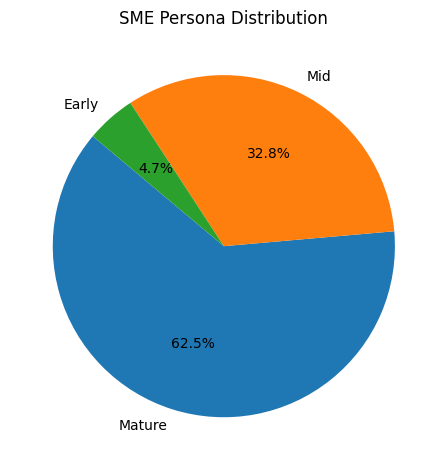

In [ ]:
import matplotlib.pyplot as plt

df['SME Persona'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, title='SME Persona Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()